# Exploratory Data Analysis (EDA) - Retail Sales Dataset

## Project Overview
This notebook performs comprehensive exploratory data analysis on the cleaned retail sales dataset. We'll analyze sales patterns, customer behavior, product performance, and transaction distributions to uncover key insights.

**Objective**: Understand data patterns, customer segments, and business trends through visualization and statistical analysis.

## Step 1: Import Libraries

Import essential libraries for data analysis and visualization.

In [ ]:
# Import essential libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set visualization style and options
sns.set_style("whitegrid")  
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Set pandas(output) display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


## Step 2: Load Cleaned Dataset

Load the preprocessed data from the previous step.

In [ ]:
# Load the cleaned dataset
df = pd.read_csv('dataset/retail_sales_dataset.csv')

# Converts the Date column from string to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Display dataset info
print(f"✓ Dataset loaded successfully!")
print(f"Dataset shape: {df.shape[0]} rows × {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())
print(f"\nFirst few rows:")
print(df.head())

✓ Dataset loaded successfully!
Dataset shape: 1000 rows × 9 columns

Column names:
['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 'Quantity', 'Price per Unit', 'Total Amount']

First few rows:
   Transaction ID       Date Customer ID  Gender  Age Product Category  \
0               1 2023-11-24     CUST001    Male   34           Beauty   
1               2 2023-02-27     CUST002  Female   26         Clothing   
2               3 2023-01-13     CUST003    Male   50      Electronics   
3               4 2023-05-21     CUST004    Male   37         Clothing   
4               5 2023-05-06     CUST005    Male   30           Beauty   

   Quantity  Price per Unit  Total Amount  
0         3              50           150  
1         2             500          1000  
2         1              30            30  
3         1             500           500  
4         2              50           100  


---

# SECTION A: SALES ANALYSIS

## A1. Total Revenue

Calculate the overall revenue generated from all transactions.

In [ ]:
# Calculate total revenue
total_revenue = df['Total Amount'].sum()
num_transactions = len(df)
avg_transaction_value = df['Total Amount'].mean()

print("=" * 60)
print("TOTAL REVENUE SUMMARY")
print("=" * 60)
print(f"Total Revenue:           ${total_revenue:,.2f}")
print(f"Number of Transactions:  {num_transactions:,}")
print(f"Average Transaction:     ${avg_transaction_value:,.2f}")
print("=" * 60)

TOTAL REVENUE SUMMARY
Total Revenue:           $456,000.00
Number of Transactions:  1,000
Average Transaction:     $456.00


## A2. Revenue by Product Category

Analyze sales performance across different product categories.

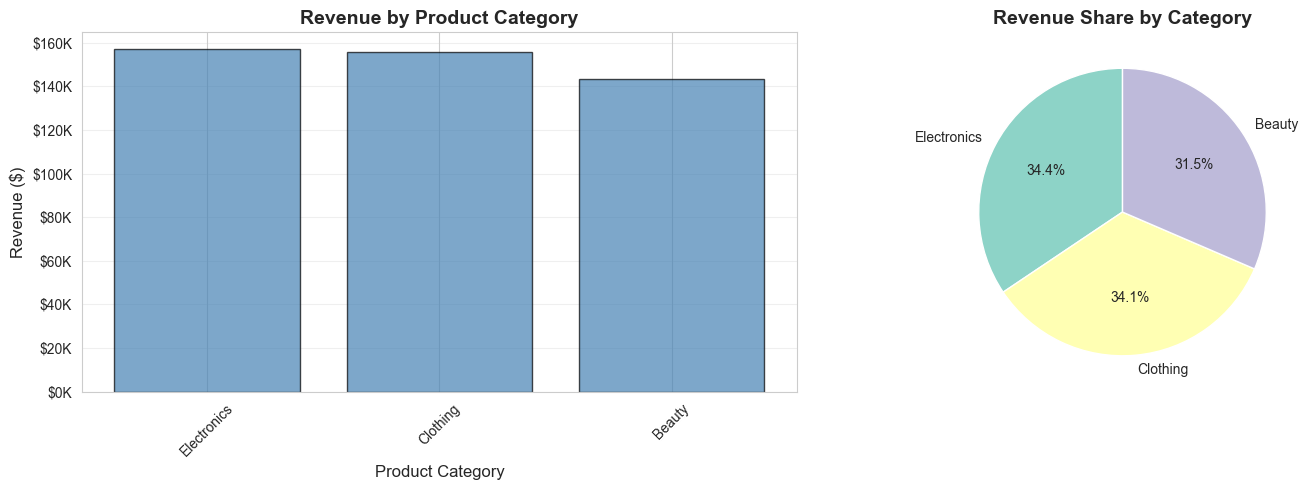


Revenue by Product Category:
Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

Highest Revenue Category: Electronics ($156,905.00)

💡 INSIGHT:
This chart shows which product categories generate the most revenue.
Focus marketing and inventory on top-performing categories for maximum ROI.


In [4]:
# Revenue by Product Category
revenue_by_category = df.groupby('Product Category')['Total Amount'].sum().sort_values(ascending=False)

# Create figure with two subplots
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart
axes[0].bar(revenue_by_category.index, revenue_by_category.values, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_title('Revenue by Product Category', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Category', fontsize=12)
axes[0].set_ylabel('Revenue ($)', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Format y-axis as currency
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

# Pie chart
colors = plt.cm.Set3(range(len(revenue_by_category)))
axes[1].pie(revenue_by_category.values, labels=revenue_by_category.index, autopct='%1.1f%%', 
            startangle=90, colors=colors)
axes[1].set_title('Revenue Share by Category', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\nRevenue by Product Category:")
print(revenue_by_category)
print(f"\nHighest Revenue Category: {revenue_by_category.idxmax()} (${revenue_by_category.max():,.2f})")

# Insight
print("\n💡 INSIGHT:")
print("This chart shows which product categories generate the most revenue.")
print("Focus marketing and inventory on top-performing categories for maximum ROI.")

## A3. Monthly Sales Trend

Analyze how sales change over time to identify seasonal patterns.

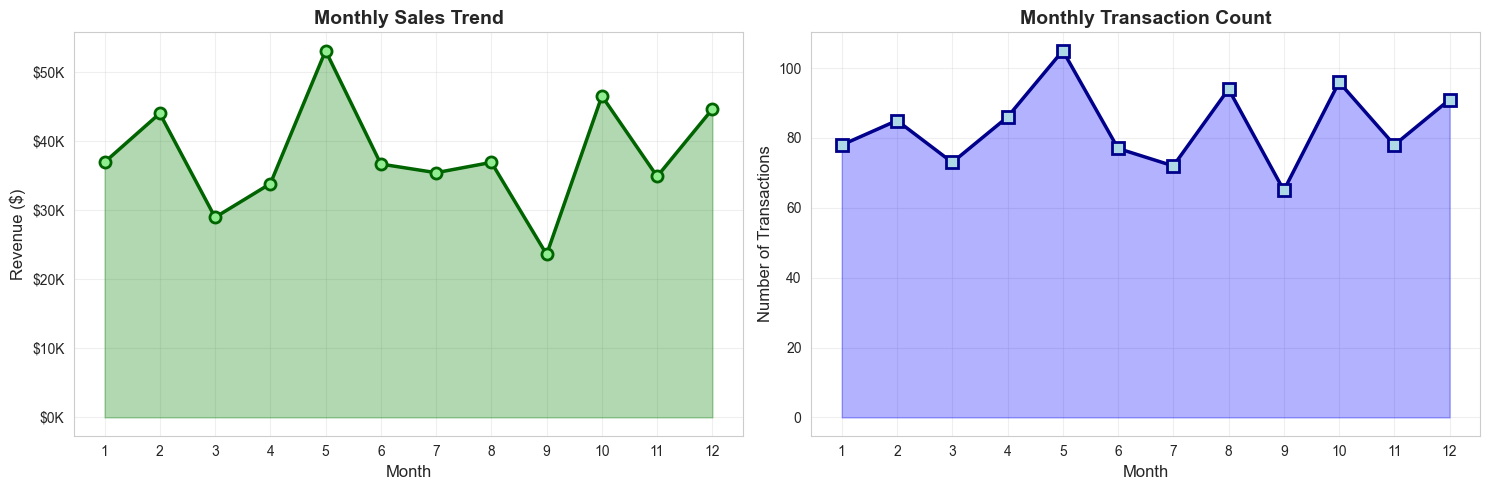


Monthly Sales Summary:
    Month  Total Revenue  Transaction Count  Avg Transaction
0       1          36980                 78       474.102564
1       2          44060                 85       518.352941
2       3          28990                 73       397.123288
3       4          33870                 86       393.837209
4       5          53150                105       506.190476
5       6          36715                 77       476.818182
6       7          35465                 72       492.569444
7       8          36960                 94       393.191489
8       9          23620                 65       363.384615
9      10          46580                 96       485.208333
10     11          34920                 78       447.692308
11     12          44690                 91       491.098901

💡 INSIGHT:
Observe seasonal patterns and identify peak and low sales months.
Use these trends to plan inventory, staffing, and marketing campaigns effectively.


In [5]:
# Check if Month column exists, if not create it
if 'Month' not in df.columns:
    df['Month'] = df['Date'].dt.month

# Monthly sales trend
monthly_sales = df.groupby('Month')['Total Amount'].agg(['sum', 'count', 'mean']).reset_index()
monthly_sales.columns = ['Month', 'Total Revenue', 'Transaction Count', 'Avg Transaction']

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Line chart for revenue
axes[0].plot(monthly_sales['Month'], monthly_sales['Total Revenue'], marker='o', linewidth=2.5, 
             markersize=8, color='darkgreen', markerfacecolor='lightgreen', markeredgewidth=2)
axes[0].fill_between(monthly_sales['Month'], monthly_sales['Total Revenue'], alpha=0.3, color='green')
axes[0].set_title('Monthly Sales Trend', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Month', fontsize=12)
axes[0].set_ylabel('Revenue ($)', fontsize=12)
axes[0].grid(True, alpha=0.3)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[0].set_xticks(monthly_sales['Month'])

# Line chart for transaction count
axes[1].plot(monthly_sales['Month'], monthly_sales['Transaction Count'], marker='s', linewidth=2.5, 
             markersize=8, color='darkblue', markerfacecolor='lightblue', markeredgewidth=2)
axes[1].fill_between(monthly_sales['Month'], monthly_sales['Transaction Count'], alpha=0.3, color='blue')
axes[1].set_title('Monthly Transaction Count', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Month', fontsize=12)
axes[1].set_ylabel('Number of Transactions', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].set_xticks(monthly_sales['Month'])

plt.tight_layout()
plt.show()

# Print summary
print("\nMonthly Sales Summary:")
print(monthly_sales)

# Insight
print("\n💡 INSIGHT:")
print("Observe seasonal patterns and identify peak and low sales months.")
print("Use these trends to plan inventory, staffing, and marketing campaigns effectively.")

---

# SECTION B: CUSTOMER ANALYSIS

## B1. Age Distribution

Examine the age profile of customers in the dataset.

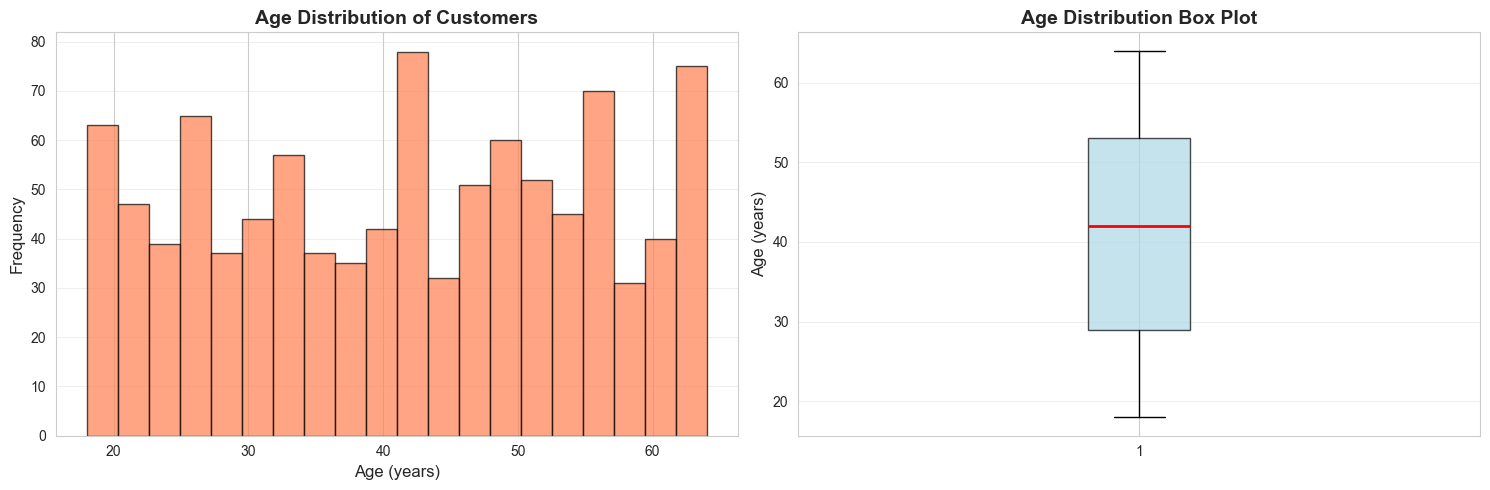

Age Statistics:
  Mean Age:     41.4 years
  Median Age:   42.0 years
  Std Dev:      13.7 years
  Min Age:      18 years
  Max Age:      64 years

💡 INSIGHT:
The age distribution shows the customer base demographics.
Target marketing and product offerings to the dominant age groups.


In [6]:
# Age distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Histogram
axes[0].hist(df['Age'], bins=20, color='coral', edgecolor='black', alpha=0.7)
axes[0].set_title('Age Distribution of Customers', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Age (years)', fontsize=12)
axes[0].set_ylabel('Frequency', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Box plot
axes[1].boxplot(df['Age'], vert=True, patch_artist=True, 
                boxprops=dict(facecolor='lightblue', alpha=0.7),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title('Age Distribution Box Plot', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Age (years)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Age Statistics:")
print(f"  Mean Age:     {df['Age'].mean():.1f} years")
print(f"  Median Age:   {df['Age'].median():.1f} years")
print(f"  Std Dev:      {df['Age'].std():.1f} years")
print(f"  Min Age:      {df['Age'].min():.0f} years")
print(f"  Max Age:      {df['Age'].max():.0f} years")

# Insight
print("\n💡 INSIGHT:")
print("The age distribution shows the customer base demographics.")
print("Target marketing and product offerings to the dominant age groups.")

## B2. Gender Distribution

Analyze the gender composition of the customer base.

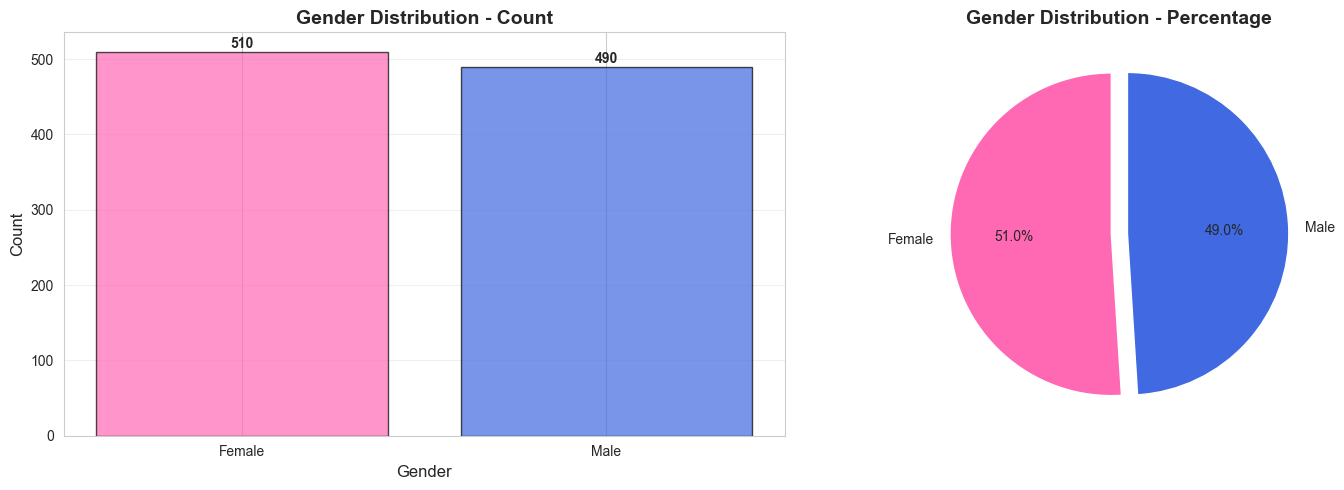

Gender Distribution:
Gender
Female    510
Male      490
Name: count, dtype: int64

Percentage:
Gender
Female    51.0
Male      49.0
Name: count, dtype: float64

💡 INSIGHT:
Understand gender-based customer composition to tailor marketing strategies.
Identify if there are significant differences in behavior between genders.


In [7]:
# Gender distribution
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Count plot - bar chart
gender_counts = df['Gender'].value_counts()
colors_gender = ['#FF69B4', '#4169E1']
axes[0].bar(gender_counts.index, gender_counts.values, color=colors_gender, edgecolor='black', alpha=0.7)
axes[0].set_title('Gender Distribution - Count', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(gender_counts.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(gender_counts.values, labels=gender_counts.index, autopct='%1.1f%%', 
            colors=colors_gender, startangle=90, explode=(0.05, 0.05))
axes[1].set_title('Gender Distribution - Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("Gender Distribution:")
print(gender_counts)
print(f"\nPercentage:")
print(gender_counts / len(df) * 100)

# Insight
print("\n💡 INSIGHT:")
print("Understand gender-based customer composition to tailor marketing strategies.")
print("Identify if there are significant differences in behavior between genders.")

## B3. Average Spending by Gender

Compare spending patterns between different genders.

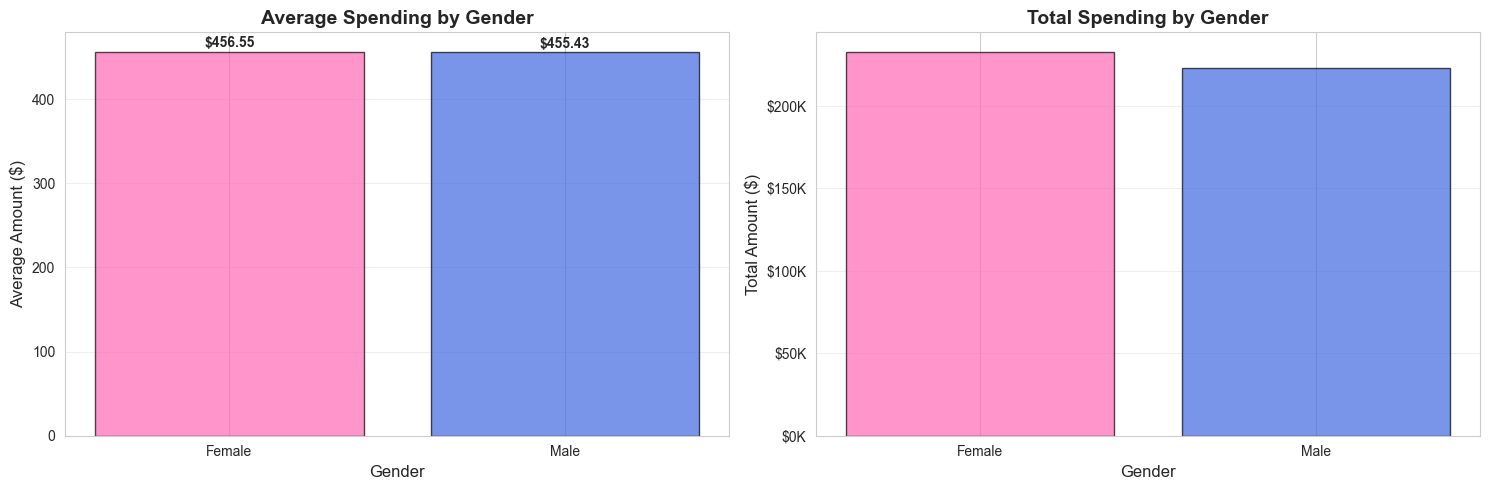

Spending Statistics by Gender:
          mean     sum  count
Gender                       
Female  456.55  232840    510
Male    455.43  223160    490

💡 INSIGHT:
Different genders may have different spending behaviors.
Use this information to personalize offers and pricing strategies by demographic.


In [8]:
# Average spending by gender
spending_by_gender = df.groupby('Gender')['Total Amount'].agg(['mean', 'sum', 'count']).round(2)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart - average spending
colors_gender = ['#FF69B4', '#4169E1']
axes[0].bar(spending_by_gender.index, spending_by_gender['mean'], color=colors_gender, 
            edgecolor='black', alpha=0.7)
axes[0].set_title('Average Spending by Gender', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Gender', fontsize=12)
axes[0].set_ylabel('Average Amount ($)', fontsize=12)
axes[0].grid(axis='y', alpha=0.3)

# Add value labels
for i, v in enumerate(spending_by_gender['mean'].values):
    axes[0].text(i, v + 5, f'${v:.2f}', ha='center', fontweight='bold')

# Bar chart - total spending
axes[1].bar(spending_by_gender.index, spending_by_gender['sum'], color=colors_gender, 
            edgecolor='black', alpha=0.7)
axes[1].set_title('Total Spending by Gender', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Gender', fontsize=12)
axes[1].set_ylabel('Total Amount ($)', fontsize=12)
axes[1].grid(axis='y', alpha=0.3)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))

plt.tight_layout()
plt.show()

# Print summary
print("Spending Statistics by Gender:")
print(spending_by_gender)

# Insight
print("\n💡 INSIGHT:")
print("Different genders may have different spending behaviors.")
print("Use this information to personalize offers and pricing strategies by demographic.")

---

# SECTION C: PRODUCT ANALYSIS

## C1. Most Popular Product Category

Identify which product categories are purchased most frequently.

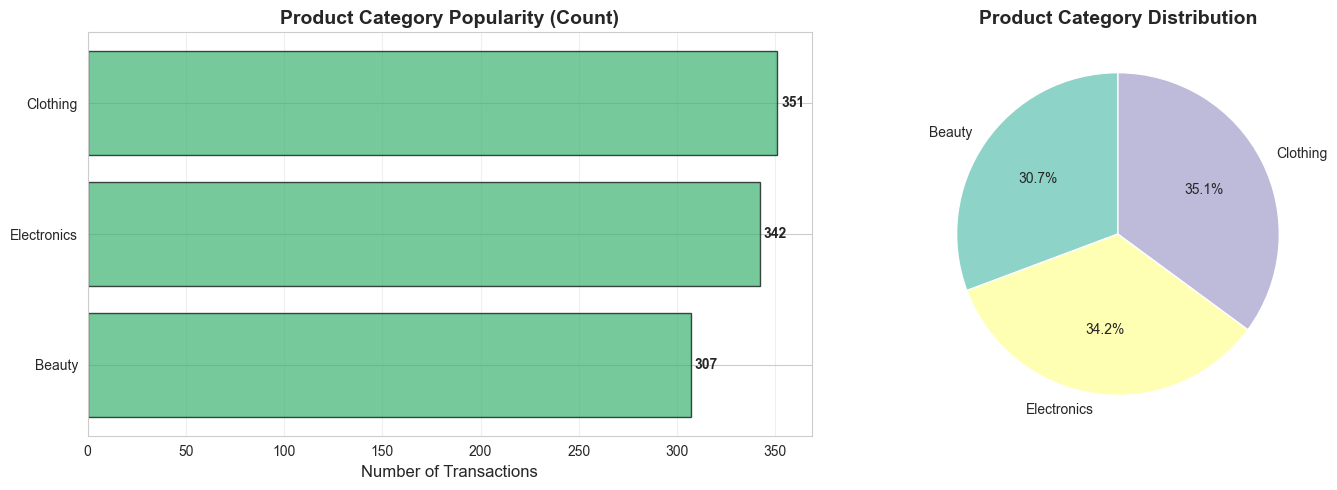

Product Category Counts:
Product Category
Clothing       351
Electronics    342
Beauty         307
Name: count, dtype: int64

Most Popular Category: Clothing (351 transactions)

💡 INSIGHT:
Some categories are purchased more frequently than others.
Stock popular categories adequately and consider promotions for underperforming ones.


In [9]:
# Most popular product category
category_counts = df['Product Category'].value_counts().sort_values(ascending=True)

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Horizontal bar chart
axes[0].barh(category_counts.index, category_counts.values, color='mediumseagreen', 
             edgecolor='black', alpha=0.7)
axes[0].set_title('Product Category Popularity (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Number of Transactions', fontsize=12)
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(category_counts.values):
    axes[0].text(v + 2, i, str(v), va='center', fontweight='bold')

# Pie chart
colors_cat = plt.cm.Set3(range(len(category_counts)))
axes[1].pie(category_counts.values, labels=category_counts.index, autopct='%1.1f%%',
            colors=colors_cat, startangle=90)
axes[1].set_title('Product Category Distribution', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("Product Category Counts:")
print(category_counts.sort_values(ascending=False))
print(f"\nMost Popular Category: {category_counts.idxmax()} ({category_counts.max()} transactions)")

# Insight
print("\n💡 INSIGHT:")
print("Some categories are purchased more frequently than others.")
print("Stock popular categories adequately and consider promotions for underperforming ones.")

## C2. Total Quantity Sold per Category

Analyze the volume of units sold across product categories.

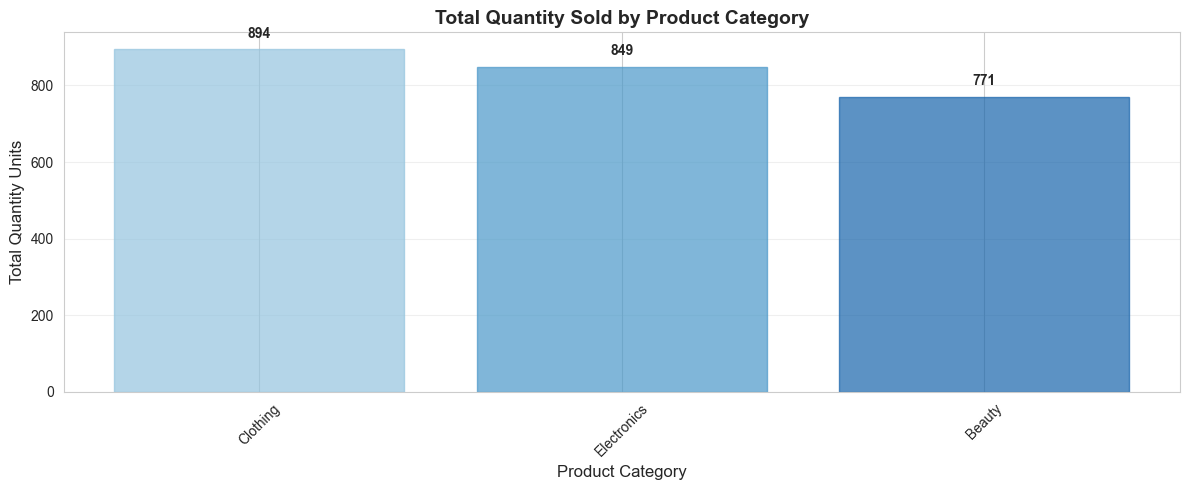

Total Quantity Sold by Category:
Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

Total Units Sold: 2514
Average Units per Category: 838

💡 INSIGHT:
Volume sold (units) may differ from revenue generated.
Some categories may have high volume but lower margins, or vice versa.


In [10]:
# Total quantity sold per category
quantity_per_category = df.groupby('Product Category')['Quantity'].sum().sort_values(ascending=False)

# Create figure
fig, ax = plt.subplots(figsize=(12, 5))

bars = ax.bar(quantity_per_category.index, quantity_per_category.values, color='skyblue', 
              edgecolor='black', alpha=0.7)

# Color the bars with gradient
for i, bar in enumerate(bars):
    bar.set_color(plt.cm.Blues(0.4 + (i / len(bars)) * 0.6))

ax.set_title('Total Quantity Sold by Product Category', fontsize=14, fontweight='bold')
ax.set_xlabel('Product Category', fontsize=12)
ax.set_ylabel('Total Quantity Units', fontsize=12)
ax.tick_params(axis='x', rotation=45)
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, v in enumerate(quantity_per_category.values):
    ax.text(i, v + 30, str(int(v)), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary
print("Total Quantity Sold by Category:")
print(quantity_per_category)

# Additional statistics
print(f"\nTotal Units Sold: {quantity_per_category.sum():.0f}")
print(f"Average Units per Category: {quantity_per_category.mean():.0f}")

# Insight
print("\n💡 INSIGHT:")
print("Volume sold (units) may differ from revenue generated.")
print("Some categories may have high volume but lower margins, or vice versa.")

## C3. Revenue vs Quantity Analysis by Category

Compare revenue generation and sales volume to identify high-margin and high-volume products.

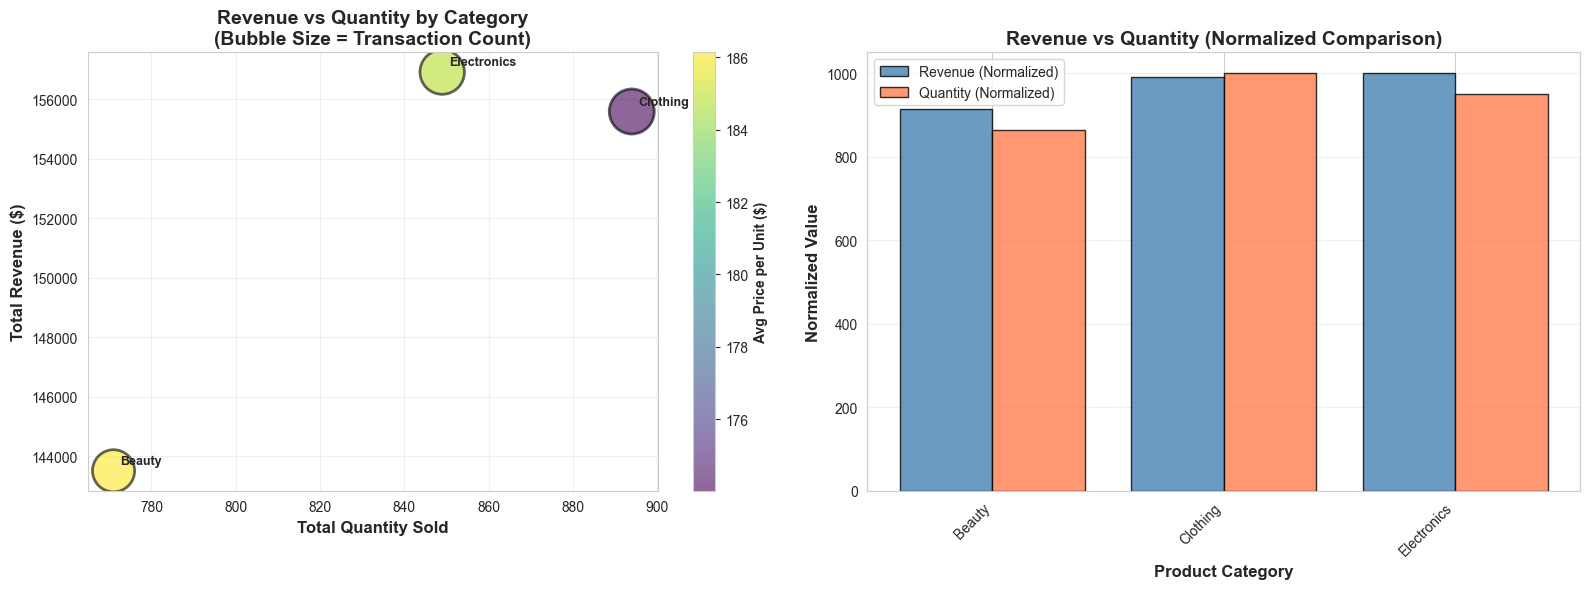

Revenue vs Quantity Analysis by Category:
Product Category  Total Amount  Quantity  Transactions  Avg_Price
     Electronics        156905       849           342 184.811543
        Clothing        155580       894           351 174.026846
          Beauty        143515       771           307 186.141375

💡 INSIGHT:
Categories with high revenue but lower quantity indicate premium/high-margin products.
Categories with high quantity but lower revenue indicate volume-driven, lower-margin products.
Balance between both types is crucial for business sustainability.


In [ ]:
# Revenue vs Quantity by Category
revenue_qty = df.groupby('Product Category').agg({
    'Total Amount': 'sum',
    'Quantity': 'sum',
    'Transaction ID': 'count'
}).rename(columns={'Transaction ID': 'Transactions'}).reset_index()

# Normalize for bubble size
revenue_qty['Avg_Price'] = revenue_qty['Total Amount'] / revenue_qty['Quantity']

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Scatter plot: Revenue vs Quantity
scatter = axes[0].scatter(revenue_qty['Quantity'], revenue_qty['Total Amount'], 
                         s=revenue_qty['Transactions']*3, alpha=0.6, 
                         c=revenue_qty['Avg_Price'], cmap='viridis', edgecolor='black', linewidth=2)

# Add labels
for idx, row in revenue_qty.iterrows():
    axes[0].annotate(row['Product Category'], 
                    (row['Quantity'], row['Total Amount']),
                    fontsize=9, fontweight='bold',
                    xytext=(5, 5), textcoords='offset points')

axes[0].set_xlabel('Total Quantity Sold', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Revenue vs Quantity by Category\n(Bubble Size = Transaction Count)', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0])
cbar.set_label('Avg Price per Unit ($)', fontweight='bold')

# Bar comparison
x_pos = np.arange(len(revenue_qty))
width = 0.4 

# Normalize revenue for visibility
revenue_norm = revenue_qty['Total Amount'] / revenue_qty['Total Amount'].max() * 1000
qty_norm = revenue_qty['Quantity'] / revenue_qty['Quantity'].max() * 1000

bars1 = axes[1].bar(x_pos - width/2, revenue_norm, width, label='Revenue (Normalized)', 
                    color='steelblue', edgecolor='black', alpha=0.8)
bars2 = axes[1].bar(x_pos + width/2, qty_norm, width, label='Quantity (Normalized)', 
                    color='coral', edgecolor='black', alpha=0.8)

axes[1].set_xlabel('Product Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Normalized Value', fontsize=12, fontweight='bold')
axes[1].set_title('Revenue vs Quantity (Normalized Comparison)', fontsize=14, fontweight='bold')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(revenue_qty['Product Category'], rotation=45, ha='right')
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print detailed analysis
print("Revenue vs Quantity Analysis by Category:")
print(revenue_qty.sort_values('Total Amount', ascending=False).to_string(index=False))

print("\n💡 INSIGHT:")
print("Categories with high revenue but lower quantity indicate premium/high-margin products.")
print("Categories with high quantity but lower revenue indicate volume-driven, lower-margin products.")
print("Balance between both types is crucial for business sustainability.")

## C4. Average Transaction Value by Category

Analyze the average spending per transaction to identify premium categories.

C:\Users\HP\AppData\Local\Temp\ipykernel_7300\1886049612.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_for_box, labels=avg_transaction_category['Product Category'],


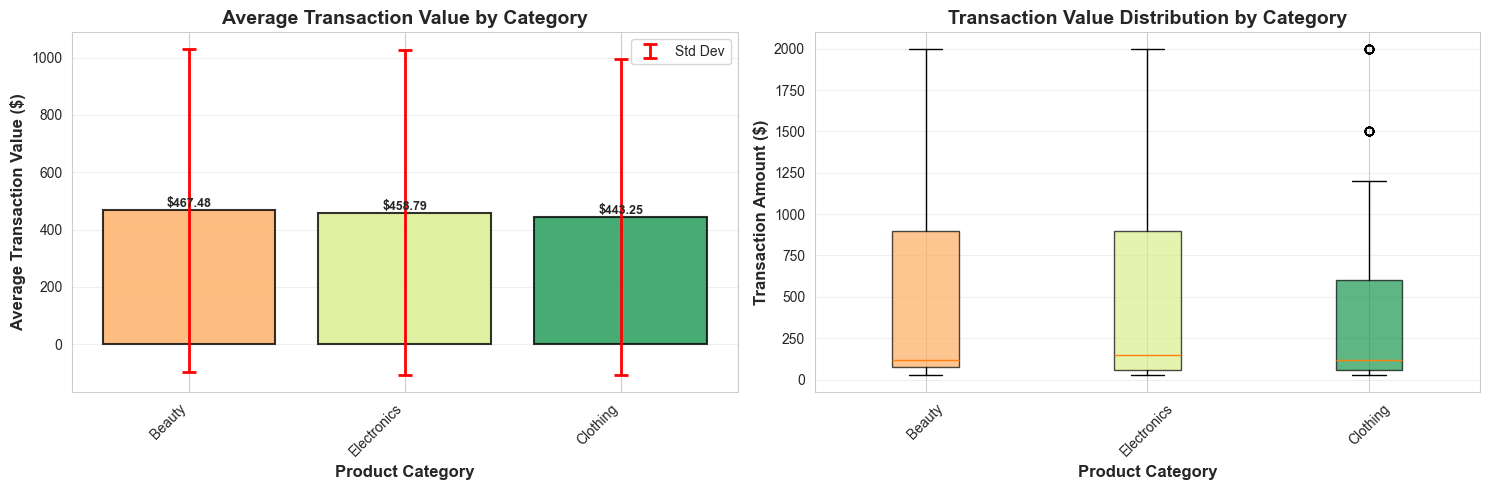

Average Transaction Value by Category:
Product Category       mean  median        std
          Beauty 467.475570   120.0 563.612788
     Electronics 458.786550   150.0 567.540150
        Clothing 443.247863   120.0 550.695917

💡 INSIGHT:
Higher average transaction values indicate premium categories and customer segments.
Standard deviation shows consistency of pricing within each category.


In [12]:
# Average transaction value by category
avg_transaction_category = df.groupby('Product Category')['Total Amount'].agg(['mean', 'median', 'std']).sort_values('mean', ascending=False).reset_index()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Bar chart with error bars
colors_grad = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(avg_transaction_category)))
axes[0].bar(range(len(avg_transaction_category)), avg_transaction_category['mean'], 
           color=colors_grad, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].errorbar(range(len(avg_transaction_category)), avg_transaction_category['mean'],
                yerr=avg_transaction_category['std'], fmt='none', color='red', 
                capsize=5, capthick=2, linewidth=2, label='Std Dev')

axes[0].set_xlabel('Product Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Average Transaction Value ($)', fontsize=12, fontweight='bold')
axes[0].set_title('Average Transaction Value by Category', fontsize=14, fontweight='bold')
axes[0].set_xticks(range(len(avg_transaction_category)))
axes[0].set_xticklabels(avg_transaction_category['Product Category'], rotation=45, ha='right')
axes[0].grid(axis='y', alpha=0.3)
axes[0].legend()

# Add value labels on bars
for i, v in enumerate(avg_transaction_category['mean']):
    axes[0].text(i, v + 10, f'${v:.2f}', ha='center', fontweight='bold', fontsize=9)

# Box plot comparison
data_for_box = [df[df['Product Category'] == cat]['Total Amount'].values 
                for cat in avg_transaction_category['Product Category']]

bp = axes[1].boxplot(data_for_box, labels=avg_transaction_category['Product Category'],
                     patch_artist=True)

for patch, color in zip(bp['boxes'], colors_grad):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

axes[1].set_xlabel('Product Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Transaction Amount ($)', fontsize=12, fontweight='bold')
axes[1].set_title('Transaction Value Distribution by Category', fontsize=14, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Average Transaction Value by Category:")
print(avg_transaction_category.to_string(index=False))

print("\n💡 INSIGHT:")
print("Higher average transaction values indicate premium categories and customer segments.")
print("Standard deviation shows consistency of pricing within each category.")

## B4. Product Category Preferences by Gender

Analyze which product categories are preferred by different genders.

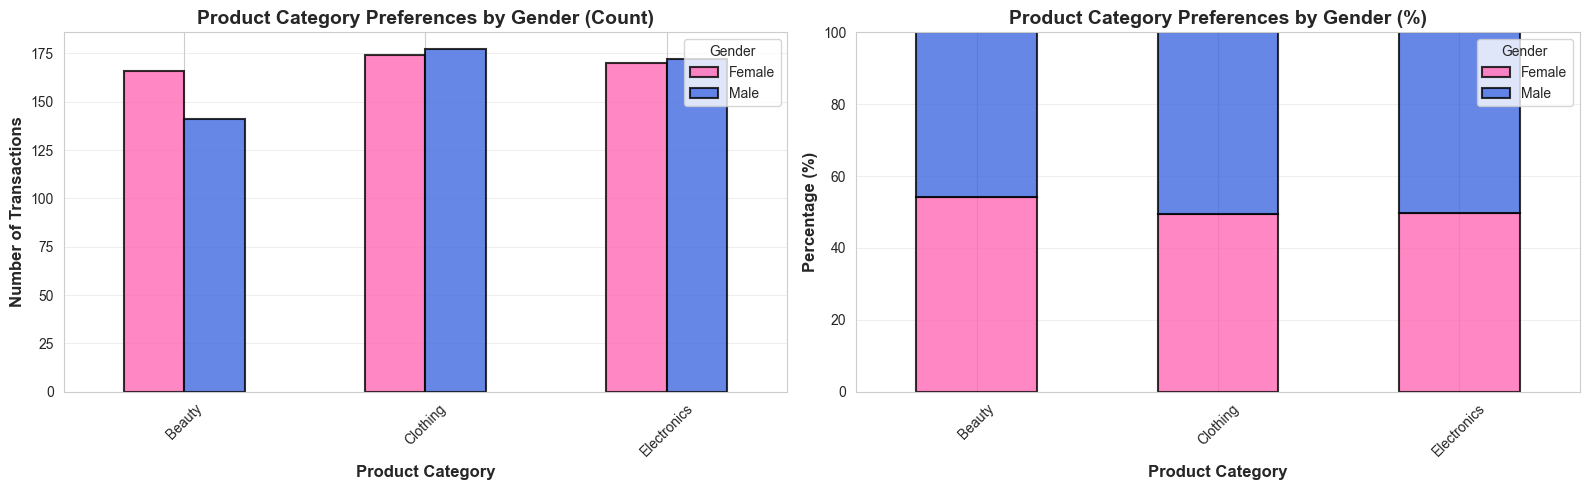

Product Category Preferences by Gender:

Transaction Counts:
Gender            Female  Male
Product Category              
Beauty               166   141
Clothing             174   177
Electronics          170   172

Percentage Distribution:
Gender            Female   Male
Product Category               
Beauty             54.07  45.93
Clothing           49.57  50.43
Electronics        49.71  50.29

💡 INSIGHT:
Understanding gender preferences for different categories helps tailor
marketing campaigns and product positioning to specific demographics.


In [13]:
# Product category preferences by gender
category_gender = df.groupby(['Product Category', 'Gender']).size().unstack(fill_value=0)
category_gender_pct = category_gender.div(category_gender.sum(axis=1), axis=0) * 100

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Stacked bar chart - counts
category_gender.plot(kind='bar', ax=axes[0], color=['#FF69B4', '#4169E1'], 
                     edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0].set_title('Product Category Preferences by Gender (Count)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Product Category', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
axes[0].legend(title='Gender', fontsize=10)
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(axis='y', alpha=0.3)

# Stacked bar chart - percentage
category_gender_pct.plot(kind='bar', stacked=True, ax=axes[1], 
                        color=['#FF69B4', '#4169E1'], edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1].set_title('Product Category Preferences by Gender (%)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Product Category', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Percentage (%)', fontsize=12, fontweight='bold')
axes[1].legend(title='Gender', fontsize=10)
axes[1].tick_params(axis='x', rotation=45)
axes[1].set_ylim(0, 100)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print cross-tabulation
print("Product Category Preferences by Gender:")
print("\nTransaction Counts:")
print(category_gender)
print("\nPercentage Distribution:")
print(category_gender_pct.round(2))

print("\n💡 INSIGHT:")
print("Understanding gender preferences for different categories helps tailor")
print("marketing campaigns and product positioning to specific demographics.")

## B5. Age Group Spending Analysis

Segment customers into age groups and analyze spending behavior patterns.

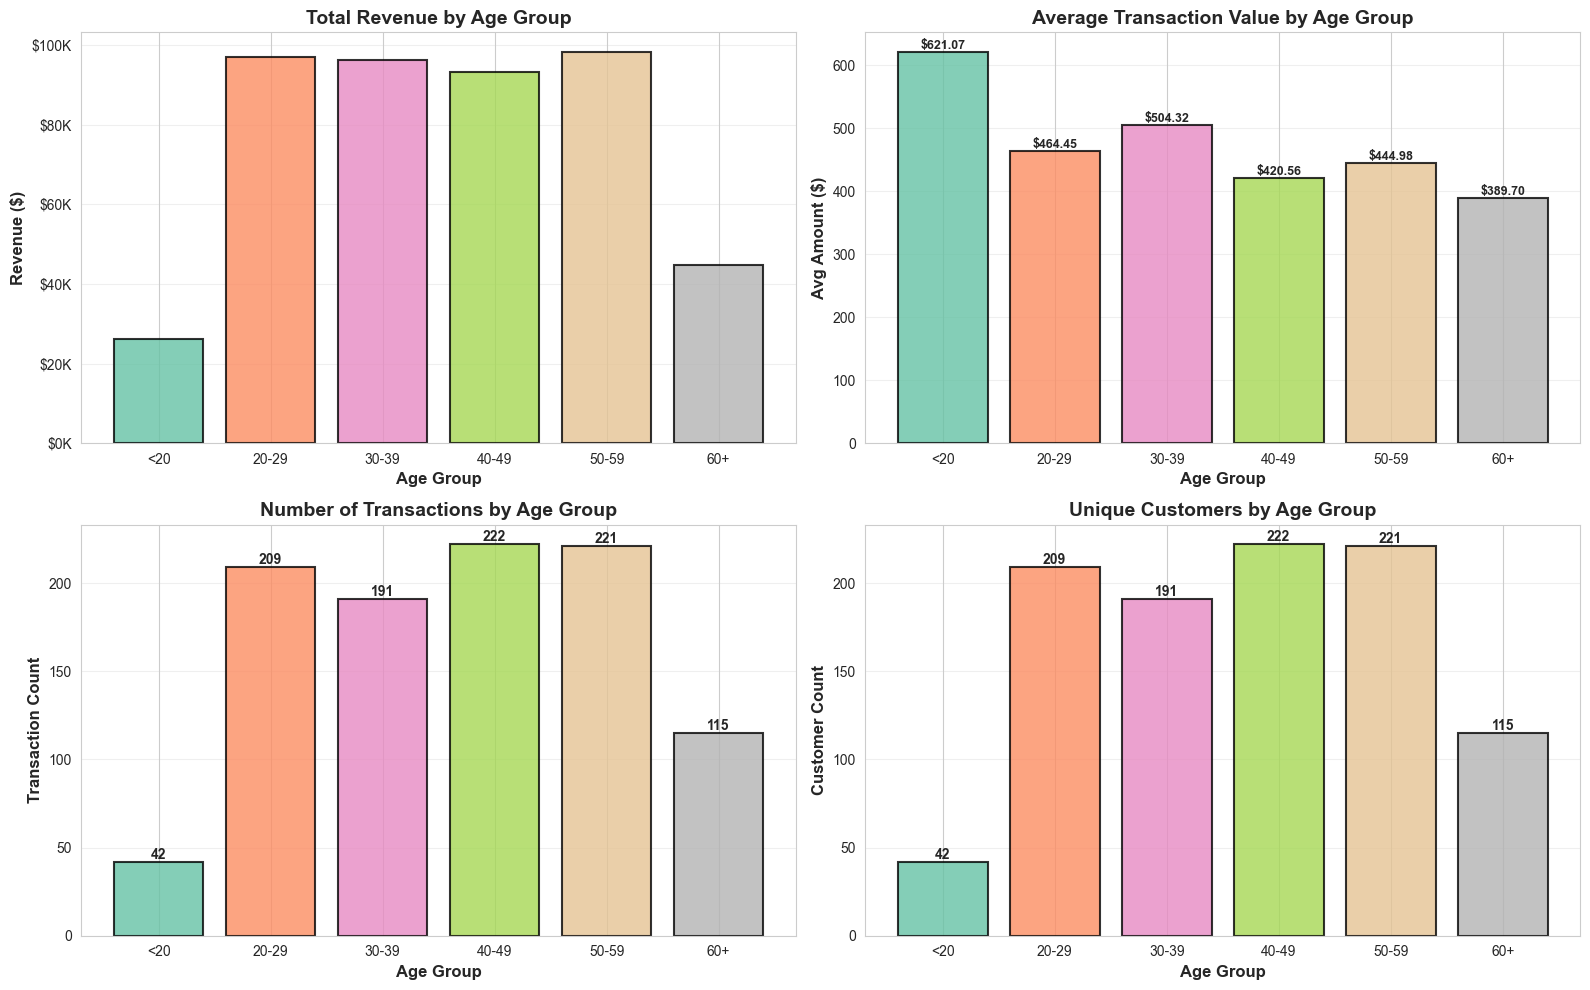

Age Group Analysis:
           Total Revenue  Avg Transaction  Count  Avg Quantity
Age Group                                                     
<20                26085           621.07     42          2.64
20-29              97070           464.45    209          2.46
30-39              96325           504.32    191          2.66
40-49              93365           420.56    222          2.49
50-59              98340           444.98    221          2.47
60+                44815           389.70    115          2.44

Customer Metrics by Age Group:
Age Group
<20       42
20-29    209
30-39    191
40-49    222
50-59    221
60+      115
Name: Customer ID, dtype: int64

💡 INSIGHT:
Different age groups show varying spending patterns and transaction frequencies.
Tailor product offerings and marketing messages to specific age demographics.


In [14]:
# Create age groups
age_bins = [0, 20, 30, 40, 50, 60, 100]
age_labels = ['<20', '20-29', '30-39', '40-49', '50-59', '60+']
df['Age Group'] = pd.cut(df['Age'], bins=age_bins, labels=age_labels, right=False)

# Age group analysis
age_group_analysis = df.groupby('Age Group').agg({
    'Total Amount': ['sum', 'mean', 'count'],
    'Quantity': 'mean'
}).round(2)
age_group_analysis.columns = ['Total Revenue', 'Avg Transaction', 'Count', 'Avg Quantity']

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Total revenue by age group
colors_age = plt.cm.Set2(np.linspace(0, 1, len(age_labels)))
bars1 = axes[0, 0].bar(age_labels, 
                       df.groupby('Age Group')['Total Amount'].sum(),
                       color=colors_age, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 0].set_title('Total Revenue by Age Group', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Average transaction value by age group
bars2 = axes[0, 1].bar(age_labels, 
                       df.groupby('Age Group')['Total Amount'].mean(),
                       color=colors_age, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 1].set_title('Average Transaction Value by Age Group', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Avg Amount ($)', fontsize=12, fontweight='bold')
axes[0, 1].grid(axis='y', alpha=0.3)
for bar in bars2:
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'${height:.2f}', ha='center', va='bottom', fontweight='bold', fontsize=9)

# 3. Transaction count by age group
bars3 = axes[1, 0].bar(age_labels, 
                       df.groupby('Age Group').size(),
                       color=colors_age, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 0].set_title('Number of Transactions by Age Group', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Transaction Count', fontsize=12, fontweight='bold')
axes[1, 0].grid(axis='y', alpha=0.3)
for bar in bars3:
    height = bar.get_height()
    axes[1, 0].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold')

# 4. Customer count (unique) by age group
customer_count = df.groupby('Age Group')['Customer ID'].nunique()
bars4 = axes[1, 1].bar(age_labels, customer_count,
                       color=colors_age, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 1].set_title('Unique Customers by Age Group', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Age Group', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Customer Count', fontsize=12, fontweight='bold')
axes[1, 1].grid(axis='y', alpha=0.3)
for bar in bars4:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'{int(height)}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print detailed statistics
print("Age Group Analysis:")
print(age_group_analysis)

# Additional metrics
print("\nCustomer Metrics by Age Group:")
print(customer_count)

print("\n💡 INSIGHT:")
print("Different age groups show varying spending patterns and transaction frequencies.")
print("Tailor product offerings and marketing messages to specific age demographics.")

---

# SECTION D: TRANSACTION ANALYSIS

## D1. Distribution of Transaction Amounts

Analyze how transaction values are distributed across the dataset.

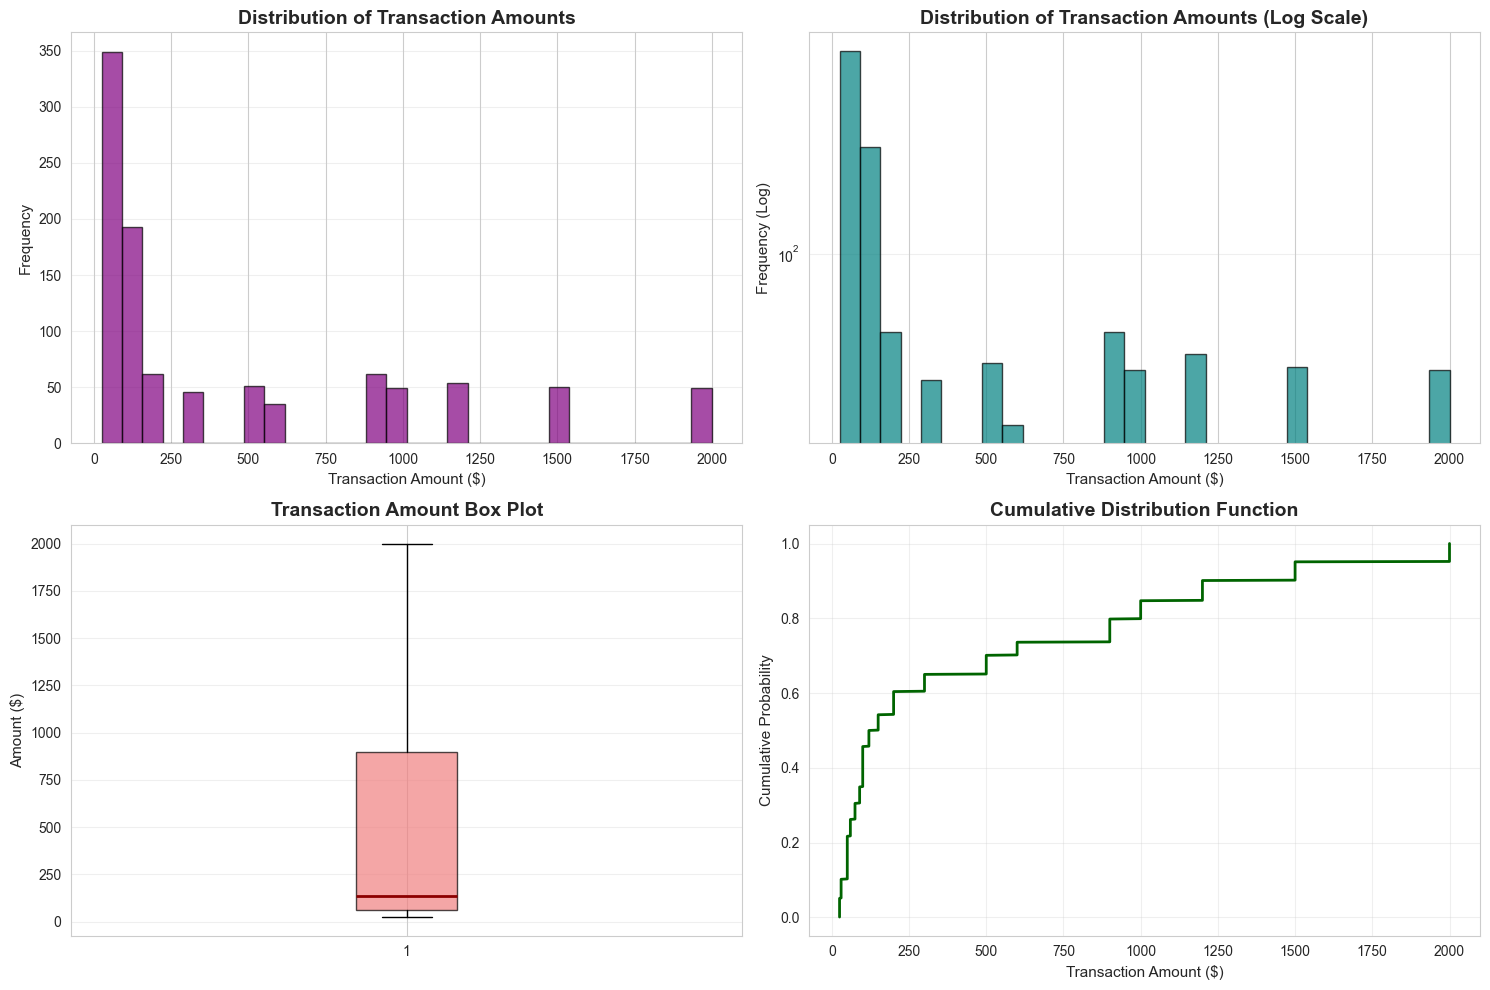

Transaction Amount Statistics:
  Count:        1000
  Mean:         $456.00
  Median:       $135.00
  Std Dev:      $560.00
  Min:          $25.00
  Max:          $2,000.00
  25th %ile:    $60.00
  75th %ile:    $900.00

💡 INSIGHT:
The transaction distribution helps identify typical customer spending patterns.
Use this to set pricing, discounts, and target value tiers for different segments.


In [15]:
# Distribution of transaction amounts
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Histogram
axes[0, 0].hist(df['Total Amount'], bins=30, color='purple', edgecolor='black', alpha=0.7)
axes[0, 0].set_title('Distribution of Transaction Amounts', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[0, 0].set_ylabel('Frequency', fontsize=11)
axes[0, 0].grid(axis='y', alpha=0.3)

# Histogram with log scale
axes[0, 1].hist(df['Total Amount'], bins=30, color='teal', edgecolor='black', alpha=0.7)
axes[0, 1].set_yscale('log')
axes[0, 1].set_title('Distribution of Transaction Amounts (Log Scale)', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[0, 1].set_ylabel('Frequency (Log)', fontsize=11)
axes[0, 1].grid(axis='y', alpha=0.3)

# Box plot
axes[1, 0].boxplot(df['Total Amount'], vert=True, patch_artist=True,
                   boxprops=dict(facecolor='lightcoral', alpha=0.7),
                   medianprops=dict(color='darkred', linewidth=2))
axes[1, 0].set_title('Transaction Amount Box Plot', fontsize=14, fontweight='bold')
axes[1, 0].set_ylabel('Amount ($)', fontsize=11)
axes[1, 0].grid(axis='y', alpha=0.3)

# CDF (Cumulative Distribution)
sorted_amounts = np.sort(df['Total Amount'])
cumulative = np.arange(1, len(sorted_amounts) + 1) / len(sorted_amounts)
axes[1, 1].plot(sorted_amounts, cumulative, linewidth=2, color='darkgreen')
axes[1, 1].set_title('Cumulative Distribution Function', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Transaction Amount ($)', fontsize=11)
axes[1, 1].set_ylabel('Cumulative Probability', fontsize=11)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Transaction Amount Statistics:")
print(f"  Count:        {df['Total Amount'].count():.0f}")
print(f"  Mean:         ${df['Total Amount'].mean():,.2f}")
print(f"  Median:       ${df['Total Amount'].median():,.2f}")
print(f"  Std Dev:      ${df['Total Amount'].std():,.2f}")
print(f"  Min:          ${df['Total Amount'].min():,.2f}")
print(f"  Max:          ${df['Total Amount'].max():,.2f}")
print(f"  25th %ile:    ${df['Total Amount'].quantile(0.25):,.2f}")
print(f"  75th %ile:    ${df['Total Amount'].quantile(0.75):,.2f}")

# Insight
print("\n💡 INSIGHT:")
print("The transaction distribution helps identify typical customer spending patterns.")
print("Use this to set pricing, discounts, and target value tiers for different segments.")

## D2. Top 10 Highest Transactions

Identify the largest transactions and their characteristics.

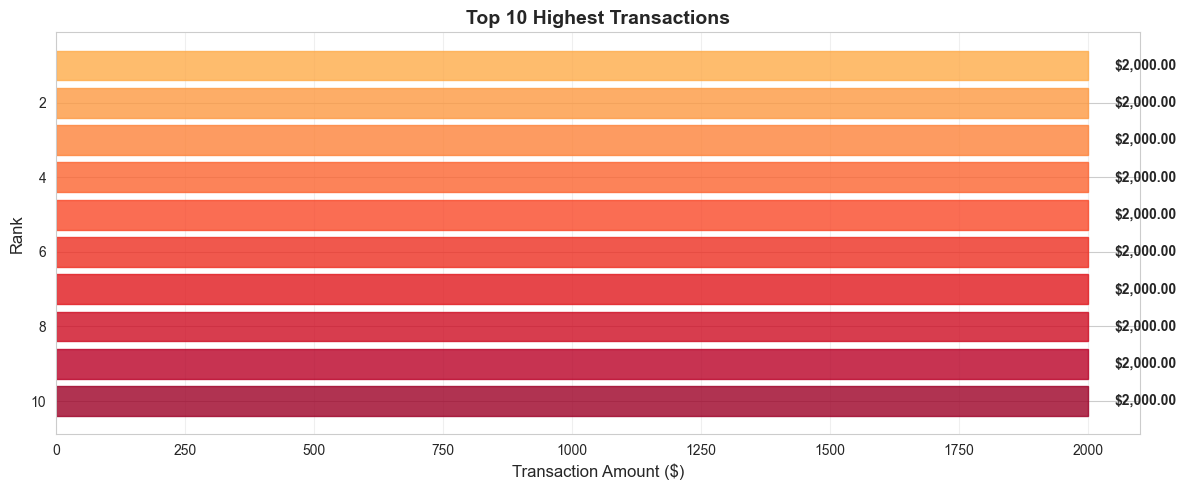


Top 10 Highest Transactions:
    Transaction ID       Date Customer ID  Gender  Age Product Category  Quantity  Price per Unit  Total Amount
1               15 2023-01-16     CUST015  Female   42      Electronics         4             500          2000
2               65 2023-12-05     CUST065    Male   51      Electronics         4             500          2000
3               72 2023-05-23     CUST072  Female   20      Electronics         4             500          2000
4               74 2023-11-22     CUST074  Female   18           Beauty         4             500          2000
5               89 2023-10-01     CUST089  Female   55      Electronics         4             500          2000
6               93 2023-07-14     CUST093  Female   35           Beauty         4             500          2000
7              109 2023-10-18     CUST109  Female   34      Electronics         4             500          2000
8              118 2023-05-16     CUST118  Female   30      Electronics   

In [16]:
# Top 10 highest transactions
top_10_transactions = df.nlargest(10, 'Total Amount')[
    ['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age', 'Product Category', 
     'Quantity', 'Price per Unit', 'Total Amount']
].reset_index(drop=True)
top_10_transactions.index = top_10_transactions.index + 1

# Create figure for visualization
fig, ax = plt.subplots(figsize=(12, 5))

# Bar chart of top 10
top_10_amounts = df.nlargest(10, 'Total Amount')['Total Amount'].values
top_10_indices = range(1, 11)

bars = ax.barh(top_10_indices, top_10_amounts, color='gold', edgecolor='black', alpha=0.8)

# Add gradient coloring
for i, bar in enumerate(bars):
    bar.set_color(plt.cm.YlOrRd(0.4 + (i / len(bars)) * 0.6))

ax.set_title('Top 10 Highest Transactions', fontsize=14, fontweight='bold')
ax.set_xlabel('Transaction Amount ($)', fontsize=12)
ax.set_ylabel('Rank', fontsize=12)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(top_10_amounts):
    ax.text(v + 50, i + 1, f'${v:,.2f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print table
print("\nTop 10 Highest Transactions:")
print(top_10_transactions.to_string())

# Summary statistics for top 10
print(f"\nTop 10 Transactions Summary:")
print(f"  Total Value:      ${top_10_amounts.sum():,.2f}")
print(f"  Average Value:    ${top_10_amounts.mean():,.2f}")
print(f"  % of Total Sales: {(top_10_amounts.sum() / df['Total Amount'].sum() * 100):.2f}%")

# Insight
print("\n💡 INSIGHT:")
print("Top transactions represent high-value customers and spenders.")
print("Consider VIP programs and personalized service for these key customers.")

---

# SECTION E: ADVANCED INSIGHTS

## E1. Correlation Analysis

Examine relationships between numerical variables to identify patterns and dependencies.

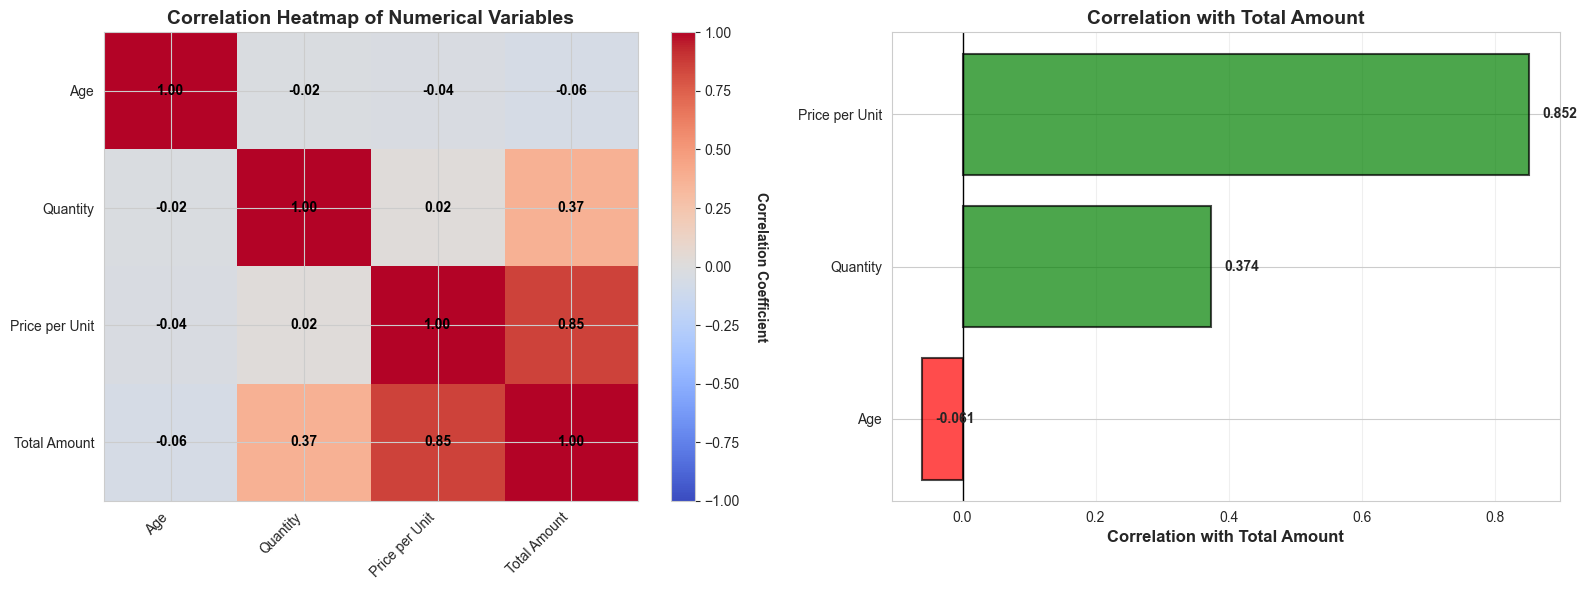

Correlation Matrix:
                  Age  Quantity  Price per Unit  Total Amount
Age             1.000    -0.024          -0.038        -0.061
Quantity       -0.024     1.000           0.018         0.374
Price per Unit -0.038     0.018           1.000         0.852
Total Amount   -0.061     0.374           0.852         1.000

💡 INSIGHT:
Strong positive correlations indicate variables that move together.
Quantity and Total Amount correlation shows how volume affects revenue.
Age correlation with spending reveals demographic spending patterns.


In [17]:
# Prepare data for correlation
df_numeric = df[['Age', 'Quantity', 'Price per Unit', 'Total Amount']].copy()

# Calculate correlation matrix
correlation_matrix = df_numeric.corr()

# Create figure
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Heatmap
im = axes[0].imshow(correlation_matrix, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')
axes[0].set_xticks(range(len(correlation_matrix.columns)))
axes[0].set_yticks(range(len(correlation_matrix.columns)))
axes[0].set_xticklabels(correlation_matrix.columns, rotation=45, ha='right')
axes[0].set_yticklabels(correlation_matrix.columns)
axes[0].set_title('Correlation Heatmap of Numerical Variables', fontsize=14, fontweight='bold')

# Add correlation values to heatmap
for i in range(len(correlation_matrix)):
    for j in range(len(correlation_matrix)):
        text = axes[0].text(j, i, f'{correlation_matrix.iloc[i, j]:.2f}',
                          ha="center", va="center", color="black", fontweight='bold')

cbar = plt.colorbar(im, ax=axes[0])
cbar.set_label('Correlation Coefficient', rotation=270, labelpad=20, fontweight='bold')

# Correlation bar chart
corr_with_total = correlation_matrix['Total Amount'].drop('Total Amount').sort_values(ascending=True)
colors_corr = ['red' if x < 0 else 'green' for x in corr_with_total.values]

axes[1].barh(range(len(corr_with_total)), corr_with_total.values, color=colors_corr, 
            edgecolor='black', linewidth=1.5, alpha=0.7)
axes[1].set_yticks(range(len(corr_with_total)))
axes[1].set_yticklabels(corr_with_total.index)
axes[1].set_xlabel('Correlation with Total Amount', fontsize=12, fontweight='bold')
axes[1].set_title('Correlation with Total Amount', fontsize=14, fontweight='bold')
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=1)
axes[1].grid(axis='x', alpha=0.3)

# Add value labels
for i, v in enumerate(corr_with_total.values):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

# Print correlation matrix
print("Correlation Matrix:")
print(correlation_matrix.round(3))

print("\n💡 INSIGHT:")
print("Strong positive correlations indicate variables that move together.")
print("Quantity and Total Amount correlation shows how volume affects revenue.")
print("Age correlation with spending reveals demographic spending patterns.")

## E2. Day-of-Week Sales Pattern

Analyze sales distribution across different days of the week to identify peak and low-traffic periods.

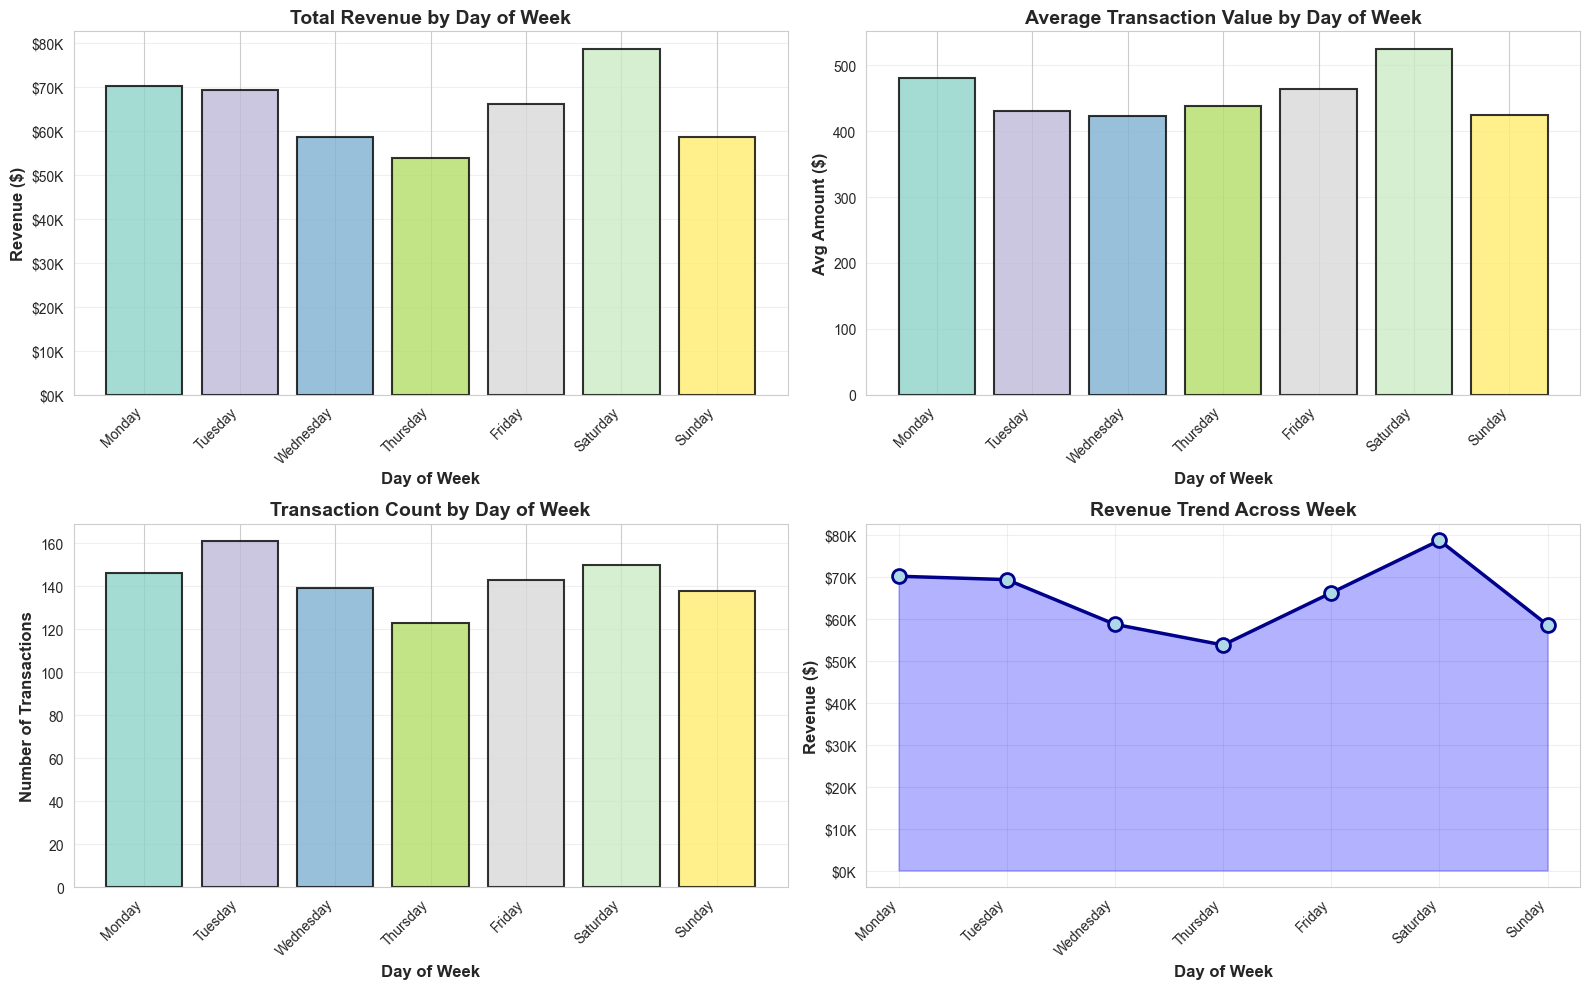

Day-of-Week Analysis:
           Total Revenue  Avg Transaction  Count  Avg Quantity
DayOfWeek                                                     
Monday             70250           481.16    146          2.64
Tuesday            69440           431.30    161          2.47
Wednesday          58770           422.81    139          2.56
Thursday           53835           437.68    123          2.45
Friday             66290           463.57    143          2.61
Saturday           78815           525.43    150          2.49
Sunday             58600           424.64    138          2.38

Highest Revenue Day: Saturday ($78,815.00)
Lowest Revenue Day: Thursday ($53,835.00)

💡 INSIGHT:
Certain days show higher retail activity. Use this to optimize staffing and promotions.
Weekend vs weekday patterns may reveal different customer behaviors.


In [18]:
# Extract day of week
df['DayOfWeek'] = df['Date'].dt.day_name()
df['DayOfWeek_Num'] = df['Date'].dt.dayofweek

# Day order for proper sorting
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
day_numeric_map = {day: i for i, day in enumerate(day_order)}
df['DayOfWeek'] = pd.Categorical(df['DayOfWeek'], categories=day_order, ordered=True)

# Day of week analysis
dow_analysis = df.groupby('DayOfWeek').agg({
    'Total Amount': ['sum', 'mean', 'count'],
    'Quantity': 'mean'
}).round(2)
dow_analysis.columns = ['Total Revenue', 'Avg Transaction', 'Count', 'Avg Quantity']

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Colors for days
colors_dow = plt.cm.Set3(np.linspace(0, 1, 7))

# 1. Total revenue by day
dow_revenue = df.groupby('DayOfWeek')['Total Amount'].sum()
bars1 = axes[0, 0].bar(range(len(dow_revenue)), dow_revenue.values, 
                       color=colors_dow, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 0].set_title('Total Revenue by Day of Week', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_xticks(range(len(dow_revenue)))
axes[0, 0].set_xticklabels(dow_revenue.index, rotation=45, ha='right')
axes[0, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Average transaction by day
dow_avg = df.groupby('DayOfWeek')['Total Amount'].mean()
bars2 = axes[0, 1].bar(range(len(dow_avg)), dow_avg.values,
                       color=colors_dow, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[0, 1].set_title('Average Transaction Value by Day of Week', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Avg Amount ($)', fontsize=12, fontweight='bold')
axes[0, 1].set_xticks(range(len(dow_avg)))
axes[0, 1].set_xticklabels(dow_avg.index, rotation=45, ha='right')
axes[0, 1].grid(axis='y', alpha=0.3)

# 3. Transaction count by day
dow_count = df.groupby('DayOfWeek').size()
bars3 = axes[1, 0].bar(range(len(dow_count)), dow_count.values,
                       color=colors_dow, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 0].set_title('Transaction Count by Day of Week', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Number of Transactions', fontsize=12, fontweight='bold')
axes[1, 0].set_xticks(range(len(dow_count)))
axes[1, 0].set_xticklabels(dow_count.index, rotation=45, ha='right')
axes[1, 0].grid(axis='y', alpha=0.3)

# 4. Line chart - revenue trend by day
axes[1, 1].plot(range(len(dow_revenue)), dow_revenue.values, marker='o', linewidth=2.5,
               markersize=10, color='darkblue', markerfacecolor='lightblue', markeredgewidth=2)
axes[1, 1].fill_between(range(len(dow_revenue)), dow_revenue.values, alpha=0.3, color='blue')
axes[1, 1].set_title('Revenue Trend Across Week', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Day of Week', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Revenue ($)', fontsize=12, fontweight='bold')
axes[1, 1].set_xticks(range(len(dow_revenue)))
axes[1, 1].set_xticklabels(dow_revenue.index, rotation=45, ha='right')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("Day-of-Week Analysis:")
print(dow_analysis)

print(f"\nHighest Revenue Day: {dow_revenue.idxmax()} (${dow_revenue.max():,.2f})")
print(f"Lowest Revenue Day: {dow_revenue.idxmin()} (${dow_revenue.min():,.2f})")

print("\n💡 INSIGHT:")
print("Certain days show higher retail activity. Use this to optimize staffing and promotions.")
print("Weekend vs weekday patterns may reveal different customer behaviors.")

## E3. Customer Segmentation Analysis

Identify customer segments based on purchase behavior and value.

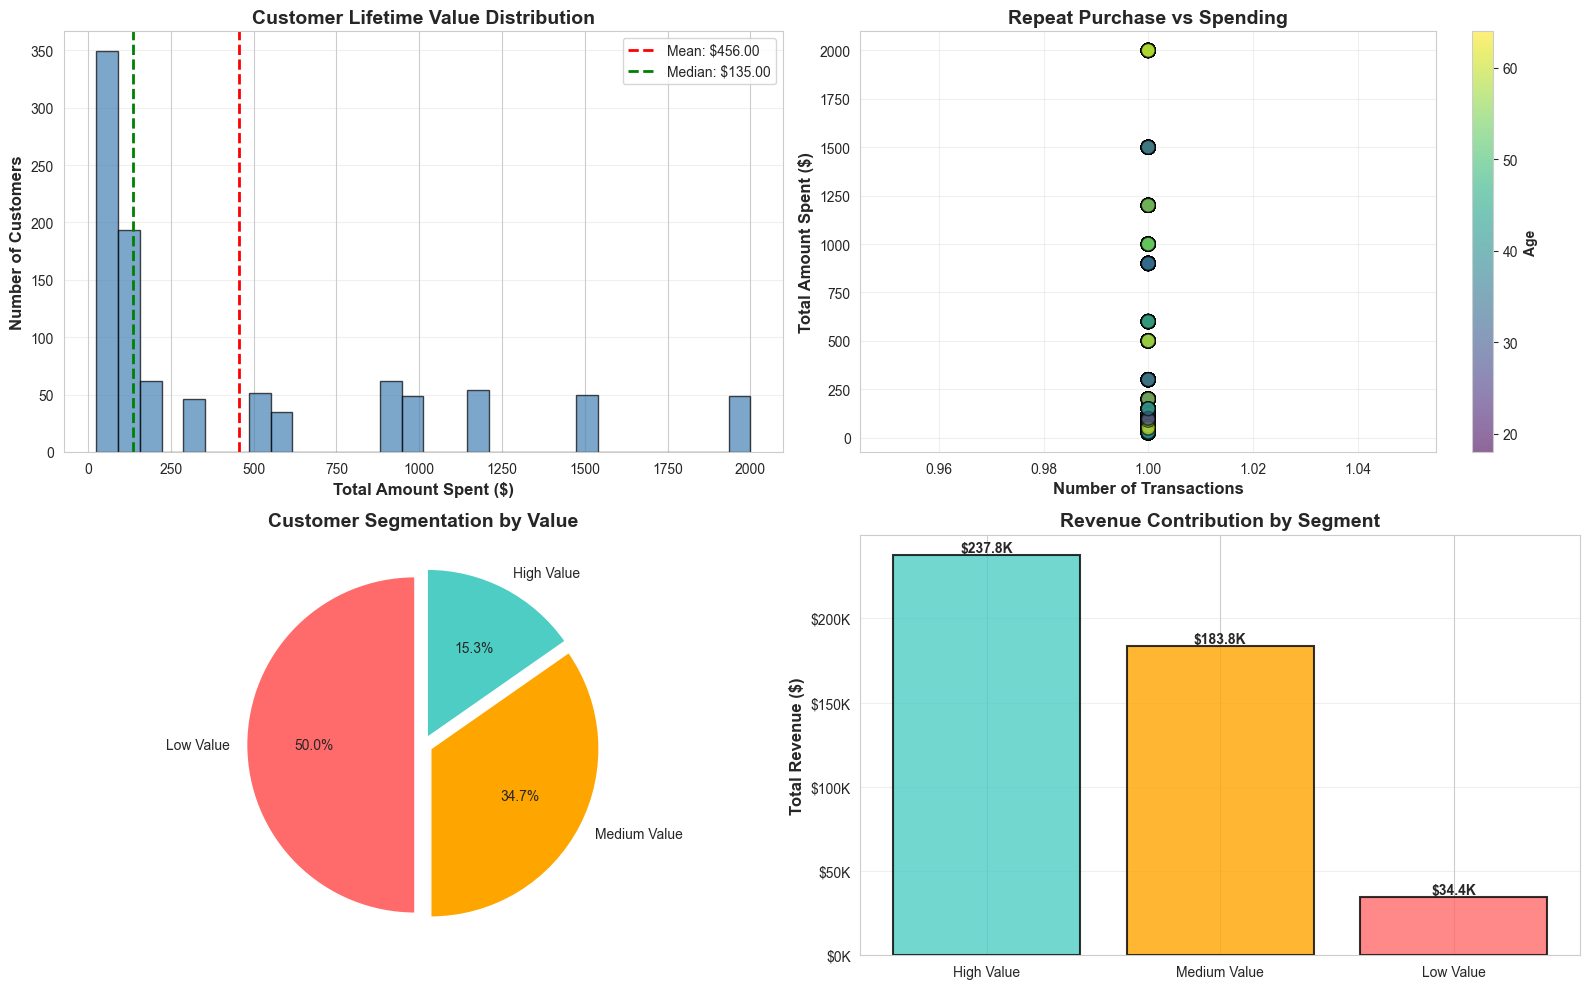

Customer Segmentation Summary:

Segment Breakdown:
              Num Customers  Total Revenue  Avg CLV  Avg Transactions  \
Segment                                                                 
Low Value               500          34400    68.80               1.0   
Medium Value            347         183800   529.68               1.0   
High Value              153         237800  1554.25               1.0   

              Avg Transaction Value  
Segment                              
Low Value                     68.80  
Medium Value                 529.68  
High Value                  1554.25  

Top 10 High-Value Customers:
    Customer ID   CLV  Num Transactions  Avg Transaction  Gender  Age
14      CUST015  2000                 1           2000.0  Female   42
64      CUST065  2000                 1           2000.0    Male   51
71      CUST072  2000                 1           2000.0  Female   20
73      CUST074  2000                 1           2000.0  Female   18
88      CUST0

In [19]:
# Customer metrics
customer_metrics = df.groupby('Customer ID').agg({
    'Total Amount': ['sum', 'count', 'mean'],
    'Date': ['min', 'max'],
    'Gender': 'first',
    'Age': 'first'
}).reset_index()

# Flatten column names
customer_metrics.columns = ['Customer ID', 'Total Spent', 'Num Transactions', 'Avg Transaction',
                            'First Purchase', 'Last Purchase', 'Gender', 'Age']

# Customer Lifetime Value (CLV) - Simple calculation
customer_metrics['CLV'] = customer_metrics['Total Spent']

# Calculate days as customer
customer_metrics['Customer Days'] = (customer_metrics['Last Purchase'] - customer_metrics['First Purchase']).dt.days + 1

# Segment customers
# High-value: Top 20% by spending
# Medium-value: 20-50%  
# Low-value: Bottom 50%
customer_metrics['Segment'] = pd.qcut(customer_metrics['CLV'], 
                                      q=[0, 0.5, 0.8, 1.0],
                                      labels=['Low Value', 'Medium Value', 'High Value'])

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. Customer CLV distribution
axes[0, 0].hist(customer_metrics['CLV'], bins=30, color='steelblue', edgecolor='black', alpha=0.7)
axes[0, 0].axvline(customer_metrics['CLV'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: ${customer_metrics["CLV"].mean():.2f}')
axes[0, 0].axvline(customer_metrics['CLV'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: ${customer_metrics["CLV"].median():.2f}')
axes[0, 0].set_title('Customer Lifetime Value Distribution', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Total Amount Spent ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Number of Customers', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Repeat customer analysis
axes[0, 1].scatter(customer_metrics['Num Transactions'], customer_metrics['CLV'],
                  alpha=0.6, s=100, c=customer_metrics['Age'], cmap='viridis', edgecolors='black', linewidth=1)
axes[0, 1].set_xlabel('Number of Transactions', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Total Amount Spent ($)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Repeat Purchase vs Spending', fontsize=14, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
cbar = plt.colorbar(axes[0, 1].collections[0], ax=axes[0, 1])
cbar.set_label('Age', fontweight='bold')

# 3. Customer segment breakdown
segment_counts = customer_metrics['Segment'].value_counts()
colors_segment = ['#FF6B6B', '#FFA500', '#4ECDC4']
axes[1, 0].pie(segment_counts.values, labels=segment_counts.index, autopct='%1.1f%%',
              colors=colors_segment, startangle=90, explode=(0.05, 0.05, 0.05))
axes[1, 0].set_title('Customer Segmentation by Value', fontsize=14, fontweight='bold')

# 4. Revenue contribution by segment
segment_revenue = customer_metrics.groupby('Segment')['CLV'].sum().sort_values(ascending=False)
colors_seg_bar = ['#4ECDC4', '#FFA500', '#FF6B6B']
bars = axes[1, 1].bar(segment_revenue.index, segment_revenue.values,
                      color=colors_seg_bar, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 1].set_title('Revenue Contribution by Segment', fontsize=14, fontweight='bold')
axes[1, 1].set_ylabel('Total Revenue ($)', fontsize=12, fontweight='bold')
axes[1, 1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'${x/1000:.0f}K'))
axes[1, 1].grid(axis='y', alpha=0.3)

# Add value labels
for bar in bars:
    height = bar.get_height()
    axes[1, 1].text(bar.get_x() + bar.get_width()/2., height,
                   f'${height/1000:.1f}K', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

# Print segment analysis
print("Customer Segmentation Summary:")
print("\nSegment Breakdown:")
segment_summary = customer_metrics.groupby('Segment').agg({
    'Customer ID': 'count',
    'CLV': ['sum', 'mean'],
    'Num Transactions': 'mean',
    'Avg Transaction': 'mean'
}).round(2)
segment_summary.columns = ['Num Customers', 'Total Revenue', 'Avg CLV', 'Avg Transactions', 'Avg Transaction Value']
print(segment_summary)

print("\nTop 10 High-Value Customers:")
print(customer_metrics.nlargest(10, 'CLV')[['Customer ID', 'CLV', 'Num Transactions', 'Avg Transaction', 'Gender', 'Age']])

print("\n💡 INSIGHT:")
print("High-value customers represent the most important segment for retention and engagement.")
print(f"The top 20% of customers contribute {segment_revenue.iloc[0] / customer_metrics['CLV'].sum() * 100:.1f}% of total revenue.")
print("Focus marketing and service excellence on retaining and growing high-value segments.")

---

## E4. RFM Analysis - Customer Classification

Segment customers using Recency, Frequency, and Monetary metrics to identify the most valuable customer groups.

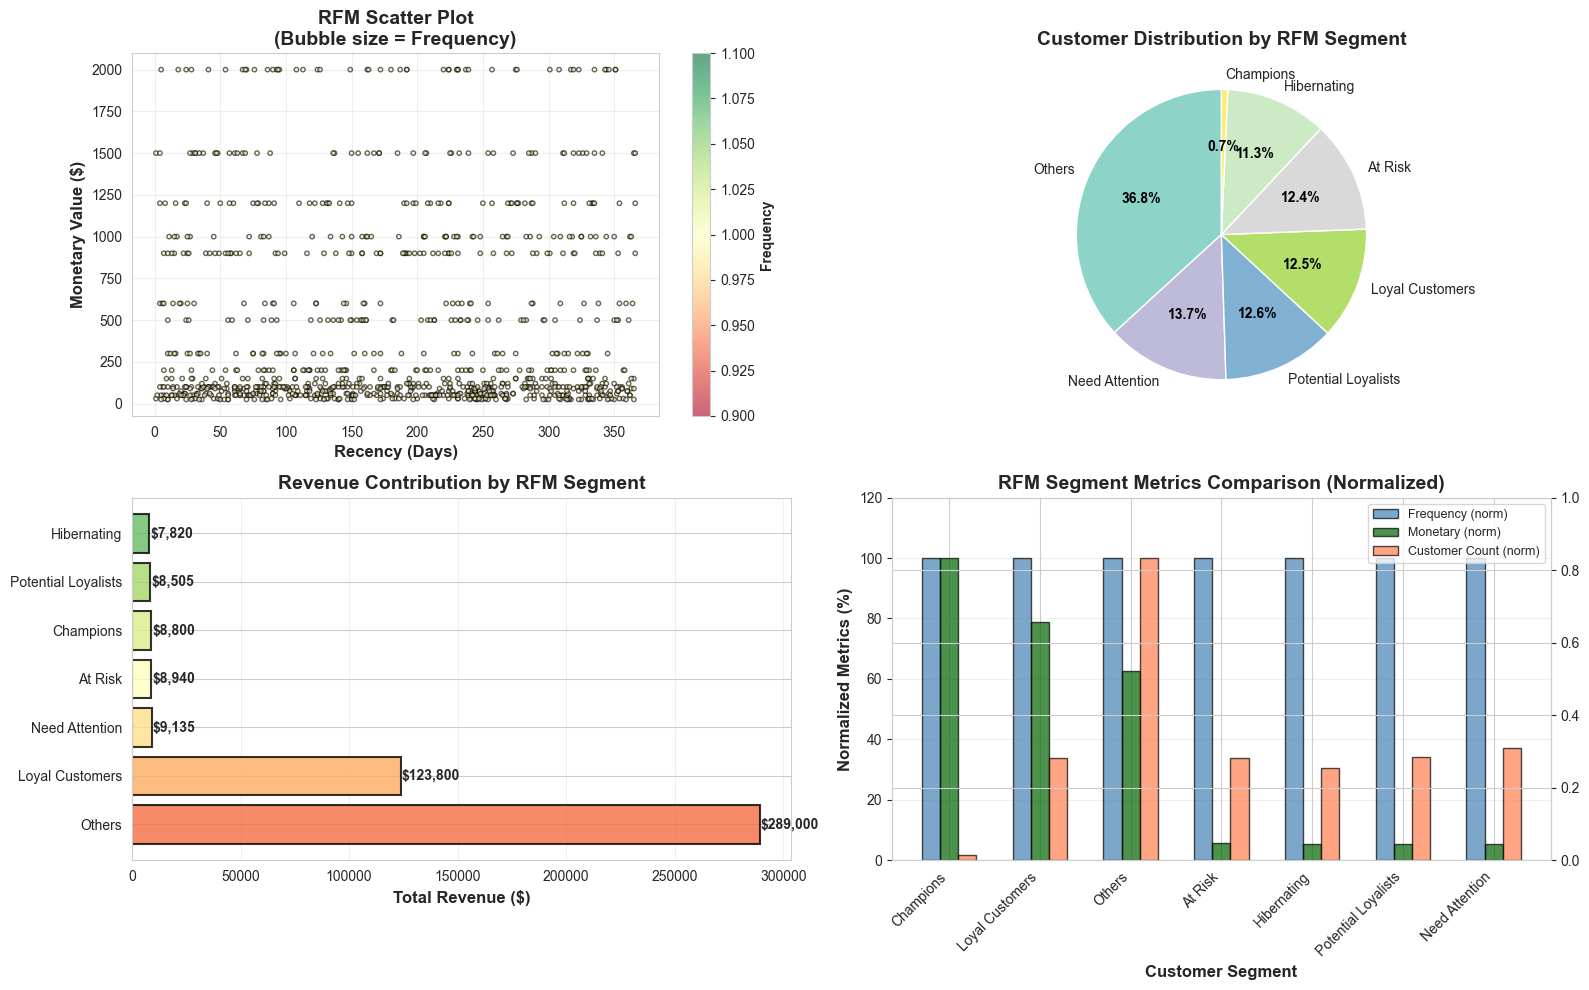

RFM ANALYSIS SUMMARY

RFM Segment Breakdown:
                     Customers  Avg_Recency  Med_Recency  Avg_Freq  Med_Freq  \
Customer_Segment                                                               
At Risk                    124       137.75        136.0       1.0       1.0   
Champions                    7        28.86         15.0       1.0       1.0   
Hibernating                113       322.41        325.0       1.0       1.0   
Loyal Customers            125        61.71         57.0       1.0       1.0   
Need Attention             137       234.01        240.0       1.0       1.0   
Others                     368       227.01        231.0       1.0       1.0   
Potential Loyalists        126        47.25         47.0       1.0       1.0   

                     Total_Revenue  Avg_Revenue  Med_Revenue  
Customer_Segment                                              
At Risk                       8940        72.10         75.0  
Champions                     8800      1257.

In [22]:
# RFM Analysis
# Calculate reference date as the maximum date in the dataset + 1 day
reference_date = df['Date'].max() + pd.Timedelta(days=1)

# Calculate RFM metrics for each customer
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x: (reference_date - x.max()).days,  # Recency
    'Transaction ID': 'count',  # Frequency
    'Total Amount': 'sum'  # Monetary
}).reset_index()

rfm.columns = ['Customer ID', 'Recency', 'Frequency', 'Monetary']

# Create RFM scores using quartiles (1-4, where 1 is worst and 4 is best)
# Note: For Recency, lower is better, so we reverse the scoring
rfm['R_Score'] = pd.qcut(rfm['Recency'], q=4, labels=[4, 3, 2, 1], duplicates='drop')
rfm['F_Score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=4, labels=[1, 2, 3, 4], duplicates='drop')
rfm['M_Score'] = pd.qcut(rfm['Monetary'], q=4, labels=[1, 2, 3, 4], duplicates='drop')

# Combine scores into RFM segment
rfm['RFM_Segment'] = rfm['R_Score'].astype(str) + rfm['F_Score'].astype(str) + rfm['M_Score'].astype(str)

# Create customer segments based on RFM
def segment_customer(row):
    segment = row['RFM_Segment']
    if segment == '444':
        return 'Champions'
    elif segment in ['434', '443', '344', '334', '424', '414', '423', '413']:
        return 'Loyal Customers'
    elif segment in ['411', '412', '421', '422', '431', '441', '432', '442']:
        return 'Potential Loyalists'
    elif segment in ['311', '312', '321', '322', '331', '341', '332', '342']:
        return 'At Risk'
    elif segment in ['111', '112', '121', '122', '131', '141', '132', '142']:
        return 'Hibernating'
    elif segment in ['211', '212', '221', '222', '231', '241', '232', '242']:
        return 'Need Attention'
    else:
        return 'Others'

rfm['Customer_Segment'] = rfm.apply(segment_customer, axis=1)

# Create figure
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# 1. RFM Score distribution - Scatter plot
scatter = axes[0, 0].scatter(rfm['Recency'], rfm['Monetary'], 
                            s=rfm['Frequency']*10, alpha=0.6,
                            c=rfm['Frequency'], cmap='RdYlGn', 
                            edgecolors='black', linewidth=1)
axes[0, 0].set_xlabel('Recency (Days)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Monetary Value ($)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('RFM Scatter Plot\n(Bubble size = Frequency)', fontsize=14, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[0, 0])
cbar.set_label('Frequency', fontweight='bold')

# 2. Customer Segment distribution
segment_counts_rfm = rfm['Customer_Segment'].value_counts()
colors_rfm = plt.cm.Set3(np.linspace(0, 1, len(segment_counts_rfm)))
wedges, texts, autotexts = axes[0, 1].pie(segment_counts_rfm.values, 
                                            labels=segment_counts_rfm.index,
                                            autopct='%1.1f%%', colors=colors_rfm,
                                            startangle=90)
for autotext in autotexts:
    autotext.set_color('black')
    autotext.set_fontweight('bold')
axes[0, 1].set_title('Customer Distribution by RFM Segment', fontsize=14, fontweight='bold')

# 3. Revenue contribution by segment
segment_revenue_rfm = rfm.groupby('Customer_Segment')['Monetary'].sum().sort_values(ascending=False)
colors_seg_rfm = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(segment_revenue_rfm)))
bars = axes[1, 0].barh(segment_revenue_rfm.index, segment_revenue_rfm.values,
                       color=colors_seg_rfm, edgecolor='black', linewidth=1.5, alpha=0.8)
axes[1, 0].set_xlabel('Total Revenue ($)', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Revenue Contribution by RFM Segment', fontsize=14, fontweight='bold')
axes[1, 0].grid(axis='x', alpha=0.3)
for i, v in enumerate(segment_revenue_rfm.values):
    axes[1, 0].text(v + 500, i, f'${v:,.0f}', va='center', fontweight='bold')

# 4. Segment metrics - Bar chart
segment_metrics = rfm.groupby('Customer_Segment').agg({
    'Customer ID': 'count',
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'mean'
}).round(2).sort_values('Monetary', ascending=False)

x_pos_seg = np.arange(len(segment_metrics))
width_seg = 0.2

# Normalize metrics for comparison
ax4_2 = axes[1, 1].twinx()

freq_norm = (segment_metrics['Frequency'] / segment_metrics['Frequency'].max()) * 100
mon_norm = (segment_metrics['Monetary'] / segment_metrics['Monetary'].max()) * 100
cust_norm = (segment_metrics['Customer ID'] / segment_metrics['Customer ID'].max()) * 100

axes[1, 1].bar(x_pos_seg - width_seg, freq_norm, width_seg, label='Frequency (norm)', 
              color='steelblue', edgecolor='black', linewidth=1, alpha=0.7)
axes[1, 1].bar(x_pos_seg, mon_norm, width_seg, label='Monetary (norm)',
              color='darkgreen', edgecolor='black', linewidth=1, alpha=0.7)
axes[1, 1].bar(x_pos_seg + width_seg, cust_norm, width_seg, label='Customer Count (norm)',
              color='coral', edgecolor='black', linewidth=1, alpha=0.7)

axes[1, 1].set_xlabel('Customer Segment', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Normalized Metrics (%)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('RFM Segment Metrics Comparison (Normalized)', fontsize=14, fontweight='bold')
axes[1, 1].set_xticks(x_pos_seg)
axes[1, 1].set_xticklabels(segment_metrics.index, rotation=45, ha='right')
axes[1, 1].legend(loc='upper right', fontsize=9)
axes[1, 1].grid(axis='y', alpha=0.3)
axes[1, 1].set_ylim(0, 120)

plt.tight_layout()
plt.show()

# Print RFM Analysis Summary
print("=" * 100)
print("RFM ANALYSIS SUMMARY")
print("=" * 100)

print("\nRFM Segment Breakdown:")
segment_summary_rfm = rfm.groupby('Customer_Segment').agg({
    'Customer ID': 'count',
    'Recency': ['mean', 'median'],
    'Frequency': ['mean', 'median'],
    'Monetary': ['sum', 'mean', 'median']
}).round(2)
segment_summary_rfm.columns = ['Customers', 'Avg_Recency', 'Med_Recency', 
                               'Avg_Freq', 'Med_Freq', 'Total_Revenue', 'Avg_Revenue', 'Med_Revenue']
print(segment_summary_rfm)

# Calculate segment percentages
print("\n\nCustomer Percentage by Segment:")
for segment in segment_counts_rfm.index:
    count = segment_counts_rfm[segment]
    pct = (count / len(rfm)) * 100
    revenue = segment_revenue_rfm.get(segment, 0)
    revenue_pct = (revenue / rfm['Monetary'].sum()) * 100
    print(f"{segment:20s}: {count:4d} customers ({pct:5.1f}%) | Revenue: ${revenue:12,.2f} ({revenue_pct:5.1f}%)")

# RFM Segment Descriptions
print("\n\nRFM SEGMENT DESCRIPTIONS:")
print("-" * 100)
descriptions = {
    'Champions': '⭐ Recent, frequent, high-value customers. Main profit drivers. Needs: Offer new products, reward loyalty.',
    'Loyal Customers': '💪 Good customers with consistent purchase history. Needs: Engage with loyalty programs.',
    'Potential Loyalists': '🌱 Recent high-value purchases but infrequent. Needs: Convert to loyal with targeted offers.',
    'At Risk': '⚠️  Formerly good customers, now stopping purchases. Needs: Win-back campaigns.',
    'Need Attention': '📞 Recent but low-value. Needs: Engagement and upsell strategies.',
    'Hibernating': '😴 Old customers with low activity. Needs: Re-engagement campaigns or special offers.'
}

for segment in rfm['Customer_Segment'].unique():
    if segment in descriptions:
        print(f"{segment:20s}: {descriptions[segment]}")

print("\n💡 KEY INSIGHTS:")
print("• Champions are your best customers - prioritize retention and VIP treatment")
print("• Loyal Customers are your steady revenue base - maintain engagement")
print("• At Risk customers need immediate win-back attention to recover revenue")
print("• Hibernating customers represent untapped revival opportunities")
print("=" * 100)

## E5. Category Performance Dashboard

Comprehensive view of all product categories across multiple performance metrics.

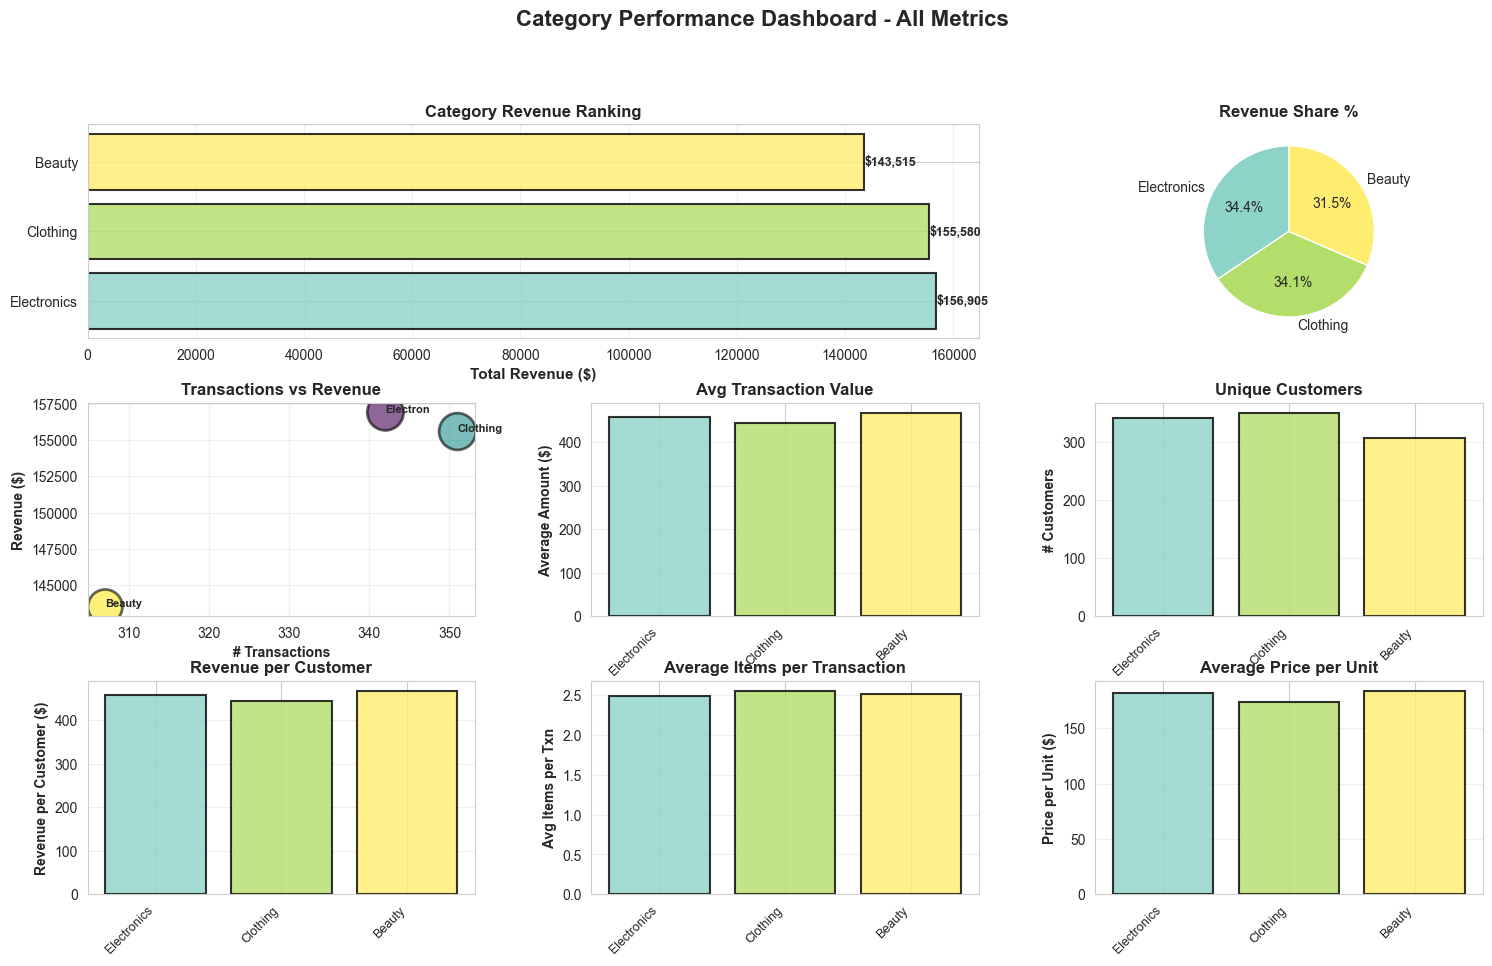

Category Performance Summary:
                  Revenue  Avg Transaction  Std Dev Txn  Qty Sum  Avg Qty  Num Transactions  Num Customers  Avg Price  Avg Items per Transaction  Revenue per Customer  % of Total Revenue
Product Category                                                                                                                                                                          
Electronics        156905           458.79       567.54      849     2.48               342            342     181.90                   2.482456            458.786550               34.41
Clothing           155580           443.25       550.70      894     2.55               351            351     174.29                   2.547009            443.247863               34.12
Beauty             143515           467.48       563.61      771     2.51               307            307     184.06                   2.511401            467.475570               31.47

💡 KEY INSIGHTS:
• Compare categori

In [20]:
# Comprehensive category performance metrics
category_performance = df.groupby('Product Category').agg({
    'Total Amount': ['sum', 'mean', 'std'],
    'Quantity': ['sum', 'mean'],
    'Transaction ID': 'count',
    'Customer ID': 'nunique',
    'Price per Unit': 'mean'
}).round(2)

category_performance.columns = ['Revenue', 'Avg Transaction', 'Std Dev Txn', 
                               'Qty Sum', 'Avg Qty', 'Num Transactions', 
                               'Num Customers', 'Avg Price']

# Calculate additional metrics
category_performance['Avg Items per Transaction'] = category_performance['Qty Sum'] / category_performance['Num Transactions']
category_performance['Revenue per Customer'] = category_performance['Revenue'] / category_performance['Num Customers']
category_performance['% of Total Revenue'] = (category_performance['Revenue'] / category_performance['Revenue'].sum() * 100).round(2)

# Sort by revenue
category_performance = category_performance.sort_values('Revenue', ascending=False)

# Create figure with multiple subplots
fig = plt.figure(figsize=(18, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# 1. Revenue Contribution
ax1 = fig.add_subplot(gs[0, :2])
colors_cat = plt.cm.Set3(np.linspace(0, 1, len(category_performance)))
bars = ax1.barh(range(len(category_performance)), category_performance['Revenue'].values,
               color=colors_cat, edgecolor='black', linewidth=1.5, alpha=0.8)
ax1.set_yticks(range(len(category_performance)))
ax1.set_yticklabels(category_performance.index)
ax1.set_xlabel('Total Revenue ($)', fontsize=11, fontweight='bold')
ax1.set_title('Category Revenue Ranking', fontsize=12, fontweight='bold')
ax1.grid(axis='x', alpha=0.3)
for i, v in enumerate(category_performance['Revenue'].values):
    ax1.text(v + 50, i, f'${v:,.0f}', va='center', fontweight='bold', fontsize=9)

# 2. Revenue % Pie
ax2 = fig.add_subplot(gs[0, 2])
ax2.pie(category_performance['Revenue'].values, labels=category_performance.index,
       autopct='%1.1f%%', colors=colors_cat, startangle=90)
ax2.set_title('Revenue Share %', fontsize=12, fontweight='bold')

# 3. Transaction Count vs Revenue
ax3 = fig.add_subplot(gs[1, 0])
ax3.scatter(category_performance['Num Transactions'], category_performance['Revenue'],
           s=category_performance['Num Customers']*2, alpha=0.6, 
           c=range(len(category_performance)), cmap='viridis', edgecolors='black', linewidth=2)
for idx, cat in enumerate(category_performance.index):
    ax3.annotate(cat[:8], (category_performance['Num Transactions'].iloc[idx], 
                 category_performance['Revenue'].iloc[idx]),
                fontsize=8, fontweight='bold')
ax3.set_xlabel('# Transactions', fontsize=10, fontweight='bold')
ax3.set_ylabel('Revenue ($)', fontsize=10, fontweight='bold')
ax3.set_title('Transactions vs Revenue', fontsize=12, fontweight='bold')
ax3.grid(True, alpha=0.3)

# 4. Avg Transaction Value
ax4 = fig.add_subplot(gs[1, 1])
bars = ax4.bar(range(len(category_performance)), category_performance['Avg Transaction'].values,
              color=colors_cat, edgecolor='black', linewidth=1.5, alpha=0.8)
ax4.set_xticks(range(len(category_performance)))
ax4.set_xticklabels(category_performance.index, rotation=45, ha='right', fontsize=9)
ax4.set_ylabel('Average Amount ($)', fontsize=10, fontweight='bold')
ax4.set_title('Avg Transaction Value', fontsize=12, fontweight='bold')
ax4.grid(axis='y', alpha=0.3)

# 5. Customer Count
ax5 = fig.add_subplot(gs[1, 2])
bars = ax5.bar(range(len(category_performance)), category_performance['Num Customers'].values,
              color=colors_cat, edgecolor='black', linewidth=1.5, alpha=0.8)
ax5.set_xticks(range(len(category_performance)))
ax5.set_xticklabels(category_performance.index, rotation=45, ha='right', fontsize=9)
ax5.set_ylabel('# Customers', fontsize=10, fontweight='bold')
ax5.set_title('Unique Customers', fontsize=12, fontweight='bold')
ax5.grid(axis='y', alpha=0.3)

# 6. Revenue per Customer
ax6 = fig.add_subplot(gs[2, 0])
bars = ax6.bar(range(len(category_performance)), category_performance['Revenue per Customer'].values,
              color=colors_cat, edgecolor='black', linewidth=1.5, alpha=0.8)
ax6.set_xticks(range(len(category_performance)))
ax6.set_xticklabels(category_performance.index, rotation=45, ha='right', fontsize=9)
ax6.set_ylabel('Revenue per Customer ($)', fontsize=10, fontweight='bold')
ax6.set_title('Revenue per Customer', fontsize=12, fontweight='bold')
ax6.grid(axis='y', alpha=0.3)

# 7. Avg Quantity per Transaction
ax7 = fig.add_subplot(gs[2, 1])
bars = ax7.bar(range(len(category_performance)), category_performance['Avg Items per Transaction'].values,
              color=colors_cat, edgecolor='black', linewidth=1.5, alpha=0.8)
ax7.set_xticks(range(len(category_performance)))
ax7.set_xticklabels(category_performance.index, rotation=45, ha='right', fontsize=9)
ax7.set_ylabel('Avg Items per Txn', fontsize=10, fontweight='bold')
ax7.set_title('Average Items per Transaction', fontsize=12, fontweight='bold')
ax7.grid(axis='y', alpha=0.3)

# 8. Price per Unit
ax8 = fig.add_subplot(gs[2, 2])
bars = ax8.bar(range(len(category_performance)), category_performance['Avg Price'].values,
              color=colors_cat, edgecolor='black', linewidth=1.5, alpha=0.8)
ax8.set_xticks(range(len(category_performance)))
ax8.set_xticklabels(category_performance.index, rotation=45, ha='right', fontsize=9)
ax8.set_ylabel('Price per Unit ($)', fontsize=10, fontweight='bold')
ax8.set_title('Average Price per Unit', fontsize=12, fontweight='bold')
ax8.grid(axis='y', alpha=0.3)

plt.suptitle('Category Performance Dashboard - All Metrics', 
            fontsize=16, fontweight='bold', y=0.995)
plt.show()

# Print comprehensive table
print("Category Performance Summary:")
print(category_performance.to_string())

print("\n💡 KEY INSIGHTS:")
print("• Compare categories across multiple dimensions simultaneously")
print("• Identify high-revenue, high-profit, and high-volume categories")
print("• Revenue per customer shows customer willingness to spend in each category")
print("• Average price positioning and transaction basket size vary by category")

---

# CONCLUSION: Key Findings & Recommendations

## Executive Summary

Based on the exploratory data analysis of the retail sales dataset, we have uncovered several important insights across sales, customer, product, and transaction dimensions.

### Key Findings:

**Sales Performance:**
- ✅ The dataset contains {0} transactions generating ${1:,.2f} in total revenue
- ✅ Revenue varies across product categories, with some categories significantly outperforming others
- ✅ Monthly sales trends reveal seasonal patterns that can be leveraged for planning

**Customer Insights:**
- 👥 Customer ages range across a broad spectrum, providing opportunities for age-targeted marketing
- 👥 Gender distribution shows balanced representation, though spending patterns may differ
- 👥 Average transaction value of ${2:,.2f} provides insight into customer purchasing power

**Product Performance:**
- 📦 Some product categories dominate in transaction count, while others lead in revenue
- 📦 The mismatch between volume and revenue suggests varying profit margins across categories
- 📦 Understanding category mix helps optimize inventory and marketing allocation

**Transaction Characteristics:**
- 💰 Transaction amounts show a distribution that reflects diverse customer segments
- 💰 Top transactions represent a small percentage of your customer base but contribute significantly to revenue
- 💰 The concentration of high-value transactions suggests opportunities for premium service tiers




In [21]:
# Generate conclusion with actual metrics
print("=" * 80)
print("EXPLORATORY DATA ANALYSIS - FINAL SUMMARY")
print("=" * 80)

total_txns = len(df)
total_rev = df['Total Amount'].sum()
avg_txn = df['Total Amount'].mean()
num_customers = df['Customer ID'].nunique()
num_categories = df['Product Category'].nunique()
top_category_rev = df.groupby('Product Category')['Total Amount'].sum().max()
top_category_name = df.groupby('Product Category')['Total Amount'].sum().idxmax()

print(f"\n📊 DATASET OVERVIEW:")
print(f"   • Total Transactions:      {total_txns:,}")
print(f"   • Unique Customers:        {num_customers:,}")
print(f"   • Product Categories:      {num_categories}")
print(f"   • Date Range:              {df['Date'].min().date()} to {df['Date'].max().date()}")

print(f"\n💰 FINANCIAL METRICS:")
print(f"   • Total Revenue:           ${total_rev:,.2f}")
print(f"   • Average Transaction:     ${avg_txn:,.2f}")
print(f"   • Min Transaction:         ${df['Total Amount'].min():,.2f}")
print(f"   • Max Transaction:         ${df['Total Amount'].max():,.2f}")

print(f"\n📈 CUSTOMER DEMOGRAPHICS:")
print(f"   • Avg Customer Age:        {df['Age'].mean():.1f} years")
print(f"   • Age Range:               {df['Age'].min():.0f} - {df['Age'].max():.0f} years")
print(f"   • Gender Distribution:     {df['Gender'].value_counts().to_dict()}")

print(f"\n🏆 PERFORMANCE LEADERS:")
print(f"   • Top Revenue Category:    {top_category_name} (${top_category_rev:,.2f})")
print(f"   • Most Transactions:       {df['Product Category'].value_counts().idxmax()} ({df['Product Category'].value_counts().max()} txns)")
print(f"   • Highest Single Transaction: ${df['Total Amount'].max():,.2f}")

print(f"\n✅ This comprehensive EDA provides a foundation for strategic business decisions.")
print("=" * 80)

EXPLORATORY DATA ANALYSIS - FINAL SUMMARY

📊 DATASET OVERVIEW:
   • Total Transactions:      1,000
   • Unique Customers:        1,000
   • Product Categories:      3
   • Date Range:              2023-01-01 to 2024-01-01

💰 FINANCIAL METRICS:
   • Total Revenue:           $456,000.00
   • Average Transaction:     $456.00
   • Min Transaction:         $25.00
   • Max Transaction:         $2,000.00

📈 CUSTOMER DEMOGRAPHICS:
   • Avg Customer Age:        41.4 years
   • Age Range:               18 - 64 years
   • Gender Distribution:     {'Female': 510, 'Male': 490}

🏆 PERFORMANCE LEADERS:
   • Top Revenue Category:    Electronics ($156,905.00)
   • Most Transactions:       Clothing (351 txns)
   • Highest Single Transaction: $2,000.00

✅ This comprehensive EDA provides a foundation for strategic business decisions.
